In [1]:
import mne
from pathlib import Path
import numpy as np

from ieeg_prep import utils

In [2]:
path_to_dir = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw")
eeg_file = "sub-EMOP0004_ses-ieeg1_task-language_acq-4_run-1_ieeg.edf"
path_to_eeg = path_to_dir/eeg_file
csv_path = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/sub-EMOP0004_ses-ieeg1_atlas-CerebrAThomasMiddle_electrodes.csv")


In [3]:
path_to_prep_dir = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/processed")
prep_file = "EMOP0004_prep_raw.fif"
path_to_prep = path_to_prep_dir / prep_file


In [4]:
#load raw and preprocessed_files
raw = mne.io.read_raw_edf(path_to_eeg, preload=True)
prep_raw = mne.io.read_raw_fif(path_to_prep, preload=True)

Extracting EDF parameters from /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/sub-EMOP0004_ses-ieeg1_task-language_acq-4_run-1_ieeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 11150015  =      0.000 ...  5444.343 secs...
Opening raw data file /storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/processed/EMOP0004_prep_raw.fif...


/tmp/ipykernel_3206293/4133543646.py:2: RuntimeWarning: Omitted 6 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(path_to_eeg, preload=True)


Isotrak not found
    Range : 0 ... 326659 =      0.000 ...  5444.317 secs
Ready.
Reading 0 ... 326659  =      0.000 ...  5444.317 secs...


In [5]:
events = mne.find_events(raw, stim_channel="TRIG")

Finding events on: TRIG
4693 events found on stim channel TRIG
Event IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12]


In [6]:
_, events_60 = raw.copy().resample(60, events=events)

In [7]:
events_60

array([[  1030,      0,      1],
       [  1061,      0,      6],
       [  1662,      0,      3],
       ...,
       [323810,      0,      4],
       [324711,      0,      4],
       [325180,      0,      5]], shape=(4693, 3))

In [8]:
prep_raw_data = prep_raw.get_data()
prep_raw_data.shape

(255, 326660)

# Extract Experimental Blocks


In [9]:
import numpy as np

def extract_blocks(events, start_code=1, end_code=2):
    """
    Extract blocks of events between start_code and end_code.

    Parameters
    ----------
    events : np.ndarray
        MNE event array of shape (n_events, 3)
    start_code : int
        Event code marking the start of a block
    end_code : int
        Event code marking the end of a block

    Returns
    -------
    blocks : list of dict
        Each dict contains information about one block.
    """

    blocks = []
    open_start_idx = None

    for i, event in enumerate(events):
        sample, _, code = event

        if code == start_code:

            if open_start_idx is not None:
                print(f"Warning: found start at event {i} before closing previous block")

                blocks.append({
                    "start_event_idx": open_start_idx,
                    "end_event_idx": None,
                    "start_sample": events[open_start_idx, 0],
                    "end_sample": None,
                    "events": events[open_start_idx:i].copy(),
                    "complete": False,
                })

            open_start_idx = i

        elif code == end_code:

            if open_start_idx is not None:
                blocks.append({
                    "start_event_idx": open_start_idx,
                    "end_event_idx": i,
                    "start_sample": events[open_start_idx, 0],
                    "end_sample": sample,
                    "events": events[open_start_idx:i+1].copy(),
                    "complete": True,
                })

                open_start_idx = None

            else:
                print(f"Warning: found end at event {i} without a matching start")

    if open_start_idx is not None:
        blocks.append({
            "start_event_idx": open_start_idx,
            "end_event_idx": None,
            "start_sample": events[open_start_idx, 0],
            "end_sample": None,
            "events": events[open_start_idx:].copy(),
            "complete": False,
        })

    return blocks

In [10]:
blocks = extract_blocks(events_60, start_code=1, end_code=2)

In [11]:
print(len(blocks))
complete_blocks = [block for block in blocks if block['end_event_idx'] is not None]
print(len(complete_blocks))

12
7


# Language Localizer Analysis

In [12]:
langloc_code = {
    1: "experiment_start",
    2: "experiment_end",
    3: "non_word",
    4: "sentence",
    5: "trial",
    6: "fixation",
    7: "subject_response",
    8: "white_screen",
    9: "probe"
}

langloc_dict = {langloc_code[key]: key for key in langloc_code.keys()}
print(langloc_dict)

{'experiment_start': 1, 'experiment_end': 2, 'non_word': 3, 'sentence': 4, 'trial': 5, 'fixation': 6, 'subject_response': 7, 'white_screen': 8, 'probe': 9}


In [13]:
langloc_blocks = []
for idx, block in enumerate(complete_blocks):
    num_trials = np.sum(np.asarray(block["events"]) == 5)
    print(f"Block {idx}: {num_trials} trials")
    num_nw_conds = np.sum(np.asarray(block["events"]) == 3)
    print(f"Block {idx}: {num_nw_conds} non word conditions")
    if num_trials == 48:
        langloc_blocks.append(block)
        

Block 0: 2 trials
Block 0: 0 non word conditions
Block 1: 48 trials
Block 1: 288 non word conditions
Block 2: 48 trials
Block 2: 288 non word conditions
Block 3: 1 trials
Block 3: 1 non word conditions
Block 4: 1 trials
Block 4: 1 non word conditions
Block 5: 3 trials
Block 5: 3 non word conditions
Block 6: 3 trials
Block 6: 3 non word conditions


In [14]:
langloc1 = langloc_blocks[0]
langloc2 = langloc_blocks[1]
conditions1 = langloc1["events"][(langloc1["events"]==4) | (langloc1["events"]==3)][0:-1:12]
conditions2 = langloc2["events"][(langloc2["events"]==4) | (langloc2["events"]==3)][0:-1:12]

conditions_1 = ['S' if cond == 4 else 'N' for cond in conditions1]
conditions_2 = ['S' if cond == 4 else 'N' for cond in conditions2]

print(conditions_1)
print(conditions_2)

['S', 'S', 'S', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'S', 'S', 'N', 'N', 'N', 'S', 'S', 'S', 'N', 'N', 'N', 'S', 'S', 'S', 'S', 'S', 'S', 'N', 'N', 'N', 'S', 'S', 'S', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'S', 'S', 'S', 'S', 'S', 'N', 'N', 'N']
['S', 'S', 'S', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'S', 'S', 'N', 'N', 'N', 'S', 'S', 'S', 'N', 'N', 'N', 'S', 'S', 'S', 'S', 'S', 'S', 'N', 'N', 'N', 'S', 'S', 'S', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'S', 'S', 'S', 'S', 'S', 'N', 'N', 'N']


### Exrtact word boundaries from each langloc trial

In [15]:
import numpy as np

def get_trial_word_boundaries_from_block(
    block,
    trial_code=5,
    word_codes=(3, 4),
    probe_code=9,
    n_words=12,
):
    """
    Parse one block dictionary and extract word boundaries for each valid trial.

    Parameters
    ----------
    block : dict
        Block dictionary with keys like:
            - start_event_idx
            - end_event_idx
            - start_sample
            - end_sample
            - events
            - complete
    trial_code : int
        Trigger code marking trial start.
    word_codes : tuple[int, ...]
        Trigger codes marking word presentations.
    probe_code : int
        Trigger code marking the probe following the last word.
    n_words : int
        Expected number of words per trial.

    Returns
    -------
    trials : list of dict
        Valid trials found within the block.
    bad_trials : list of dict
        Trials with invalid structure.
    """
    events = block["events"]
    block_start_event_idx = block["start_event_idx"]

    word_codes = set(word_codes)
    trials = []
    bad_trials = []

    trial_number = 0
    i = 0
    n_events = len(events)

    while i < n_events:
        if events[i, 2] != trial_code:
            i += 1
            continue

        trial_start_idx_local = i
        trial_start_idx_global = block_start_event_idx + i

        word_event_indices_local = []
        word_event_indices_global = []
        probe_event_idx_local = None
        probe_event_idx_global = None

        j = i + 1
        while j < n_events:
            code = events[j, 2]

            # stop if another trial begins before this one completes
            if code == trial_code:
                break

            if code in word_codes:
                word_event_indices_local.append(j)
                word_event_indices_global.append(block_start_event_idx + j)

            if code == probe_code:
                probe_event_idx_local = j
                probe_event_idx_global = block_start_event_idx + j
                break

            j += 1

        # validate structure
        if probe_event_idx_local is not None and len(word_event_indices_local) == n_words:
            word_samples = events[word_event_indices_local, 0]
            word_trigger_codes = events[word_event_indices_local, 2]
            probe_sample = events[probe_event_idx_local, 0]

            # each word runs until next word, last word runs until probe
            word_bounds = []
            for k in range(n_words - 1):
                start_sample = word_samples[k]
                end_sample = word_samples[k + 1]
                word_bounds.append((int(start_sample), int(end_sample)))

            word_bounds.append((int(word_samples[-1]), int(probe_sample)))

            trials.append({
                "block_start_event_idx": int(block_start_event_idx),
                "trial_number": trial_number,

                "trial_start_event_idx_local": int(trial_start_idx_local),
                "trial_start_event_idx_global": int(trial_start_idx_global),

                "word_event_indices_local": [int(x) for x in word_event_indices_local],
                "word_event_indices_global": [int(x) for x in word_event_indices_global],

                "word_samples": word_samples.astype(int),
                "word_codes": word_trigger_codes.astype(int),

                "probe_event_idx_local": int(probe_event_idx_local),
                "probe_event_idx_global": int(probe_event_idx_global),
                "probe_sample": int(probe_sample),

                "word_bounds": word_bounds,
            })

            trial_number += 1
            i = probe_event_idx_local + 1

        else:
            bad_trials.append({
                "block_start_event_idx": int(block_start_event_idx),
                "trial_start_event_idx_local": int(trial_start_idx_local),
                "trial_start_event_idx_global": int(trial_start_idx_global),
                "found_n_words": len(word_event_indices_local),
                "found_probe": probe_event_idx_local is not None,
            })
            i = max(i + 1, j)

    return trials, bad_trials


In [16]:

langloc1_trials, _ = get_trial_word_boundaries_from_block(langloc1)
langloc2_trials, _ = get_trial_word_boundaries_from_block(langloc2)

    

In [17]:
import numpy as np

def compute_word_starts(trials):
    """
    Given trials with 'word_bounds', compute the average (across trials)
    word start times, normalized per trial and floored to integers.

    Parameters
    ----------
    trials : list of dict
        Each trial must contain "word_bounds", where each bound is (start, end)

    Returns
    -------
    word_starts : np.ndarray
        1D array of floored mean word start times
    """

    word_starts = []

    for trial in trials:
        trial_word_starts = np.asarray([bound[0] for bound in trial["word_bounds"]])
        trial_word_starts = trial_word_starts - trial_word_starts[0]  # normalize
        word_starts.append(trial_word_starts)

    word_starts = np.asarray(word_starts)
    word_starts = word_starts.mean(axis=0)
    word_starts = np.floor(word_starts).astype(int)

    return word_starts

In [18]:
langloc1_word_starts = compute_word_starts(langloc1_trials)
langloc2_word_starts = compute_word_starts(langloc2_trials)

In [19]:
#exclude bad channels from envelope for analysis
picks = mne.pick_types(prep_raw.info, misc=True, exclude="bads")
picks.shape

envelope_data = prep_raw.get_data(picks=picks)
n_channels, _ = envelope_data.shape
envelope_data.mean()

np.float64(0.1145937994372032)

### process trials into condition average responses

In [20]:
def compute_response_vector(trials, envelope_data, langloc_dict):
    """
    Compute mean envelope response per trial and ideal response vector.

    Parameters
    ----------
    trials : list of dict
        Trial dictionaries with keys "word_bounds" and "word_codes".
    envelope_data : np.ndarray, shape (n_channels, n_samples)
        Neural data.
    langloc_dict : dict
        Must contain keys "sentence" and "non_word".

    Returns
    -------
    respvec : np.ndarray, shape (n_channels, n_trials)
        Mean envelope response per channel per trial.
    respvec_ideal : np.ndarray, shape (n_trials,)
        +1 for sentence trials, -1 for non-word trials, 0 for unknown.
    """
    n_channels = envelope_data.shape[0]
    n_trials   = len(trials)

    respvec       = np.zeros((n_channels, n_trials))
    respvec_ideal = np.zeros(n_trials)

    sentence_code = langloc_dict["sentence"]
    nonword_code  = langloc_dict["non_word"]

    for t, trial in enumerate(trials):
        stim_resp = np.zeros(n_channels)

        for start_sample, end_sample in trial["word_bounds"]:
            if envelope_data.shape[1] <= start_sample:
                print(f"Warning: trial {t} start_sample {start_sample} exceeds envelope length")
                continue
            stim_resp += envelope_data[:, start_sample:end_sample].mean(axis=1)

        respvec[:, t] = stim_resp / len(trial["word_bounds"])

        code = trial["word_codes"][0]
        if code == sentence_code:
            respvec_ideal[t] = 1
        elif code == nonword_code:
            respvec_ideal[t] = -1

    return respvec, respvec_ideal

In [21]:
langloc1_respvec, langloc1_respvec_ideal = compute_response_vector(langloc1_trials, envelope_data, langloc_dict)
langloc2_respvec, langloc2_respvec_ideal = compute_response_vector(langloc2_trials, envelope_data, langloc_dict)

### determine language channels via permuation test

In [22]:
import numpy as np
from scipy.stats import rankdata

def fast_langloc_permutation_test(langloc1_respvec, langloc1_respvec_ideal, n_perm=10000, seed=42):
    """
    Fast one-sided permutation test for each channel:
    true Spearman(obs, ideal) > 95th percentile of shuffled-label null

    Parameters
    ----------
    langloc1_respvec : array, shape (n_channels, n_trials)
        Observed responses.
    langloc1_respvec_ideal : array, shape (n_trials,)
        Ideal labels, e.g. +1 for sentence, -1 for non-word.
    n_perm : int
        Number of permutations.
    seed : int
        RNG seed.

    Returns
    -------
    true_corrs : array, shape (n_channels,)
    null_corrs : array, shape (n_channels, n_perm)
    p_values : array, shape (n_channels,)
    is_language_responsive : bool array, shape (n_channels,)
    thresholds_95 : array, shape (n_channels,)
    """
    rng = np.random.default_rng(seed)

    X = np.asarray(langloc1_respvec, dtype=float)      # (C, T)
    y = np.asarray(langloc1_respvec_ideal, dtype=float)  # (T,)

    n_channels, n_trials = X.shape

    # Rank each channel once: Spearman = Pearson on ranks
    Xr = np.apply_along_axis(rankdata, 1, X)   # (C, T)
    yr = rankdata(y)                           # (T,)

    # Center ranks
    Xc = Xr - Xr.mean(axis=1, keepdims=True)   # (C, T)
    yc = yr - yr.mean()                        # (T,)

    # Channel norms
    X_norm = np.linalg.norm(Xc, axis=1)        # (C,)
    y_norm = np.linalg.norm(yc)                # scalar

    # True Spearman for all channels at once
    true_corrs = (Xc @ yc) / (X_norm * y_norm)   # (C,)

    # Build all shuffled ideal vectors at once
    perms = np.array([rng.permutation(y) for _ in range(n_perm)])   # (P, T)

    # Rank each shuffled ideal row
    perms_r = np.apply_along_axis(rankdata, 1, perms)               # (P, T)
    perms_c = perms_r - perms_r.mean(axis=1, keepdims=True)         # (P, T)
    perms_norm = np.linalg.norm(perms_c, axis=1)                    # (P,)

    # Null correlations for all channels x permutations at once
    # result shape = (C, P)
    null_corrs = (Xc @ perms_c.T) / (X_norm[:, None] * perms_norm[None, :])

    thresholds_95 = np.percentile(null_corrs, 95, axis=1)
    is_language_responsive = true_corrs > thresholds_95

    # One-sided empirical p-value
    p_values = (np.sum(null_corrs >= true_corrs[:, None], axis=1) + 1) / (n_perm + 1)

    return true_corrs, null_corrs, p_values, is_language_responsive, thresholds_95

In [23]:
#results from each langloc
true_corrs_1, null_corrs_1, p_values_1, is_language_responsive_1, thresholds_95_1 = fast_langloc_permutation_test(langloc1_respvec, langloc1_respvec_ideal, n_perm=10000, seed=42)
true_corrs_2, null_corrs_2, p_values_2, is_language_responsive_2, thresholds_95_2 = fast_langloc_permutation_test(langloc2_respvec, langloc2_respvec_ideal, n_perm=10000, seed=42)


#results from both langlocs combine
langloc_respvec_t = np.concatenate([langloc1_respvec,langloc2_respvec], axis = 1)
langloc_respvec_ideal_t = np.concatenate([langloc1_respvec_ideal,langloc2_respvec_ideal], axis = 0)
true_corrs_t, null_corrs_t, p_values_t, is_language_responsive_t, thresholds_95_t = fast_langloc_permutation_test(langloc_respvec_t, langloc_respvec_ideal_t, n_perm=10000, seed=42)



In [24]:
print(f"Language Channels found using langloc 1: {is_language_responsive_1.sum()} channels")
print(f"Language Channels found using langloc 2: {is_language_responsive_2.sum()} channels")
print(f"Language Channels found using both langlocs: {is_language_responsive_t.sum()} channels")
print()
print(f"Overlap between langloc 1 and langloc 2: {np.sum(is_language_responsive_1&is_language_responsive_2)} channels")
print(f"Overlap between langloc 1 and langloc_both: {np.sum(is_language_responsive_1&is_language_responsive_t)} channels")
print(f"Overlap between langloc 2 and langloc_both: {np.sum(is_language_responsive_t&is_language_responsive_2)} channels")


Language Channels found using langloc 1: 10 channels
Language Channels found using langloc 2: 42 channels
Language Channels found using both langlocs: 33 channels

Overlap between langloc 1 and langloc 2: 9 channels
Overlap between langloc 1 and langloc_both: 10 channels
Overlap between langloc 2 and langloc_both: 29 channels


## Plot Language Electrodes

In [25]:
from nilearn import plotting
import matplotlib.pyplot as plt

def plot_glass_brain_masks(coords, masks, colors, labels, s=20, title="Glass Brain"):
    """
    Plot electrode coordinates on a glass brain with color-coded masks.

    Parameters
    ----------
    coords : np.ndarray, shape (n_channels, 3)
        MNI coordinates for each electrode.
    masks : list of np.ndarray of bool
        List of boolean masks, one per group.
    colors : list of str
        Color per mask group (e.g. ["red", "green"]).
    labels : list of str
        Label per mask group for the legend.
    s : int
        Scatter point size.
    title : str
        Plot title.
    """
    assert len(masks) == len(colors) == len(labels), \
        "masks, colors, and labels must all have the same length"

    # compute depth-based alpha per electrode
    z_all    = coords[:, 2]
    z_norm   = (z_all - z_all.min()) / (z_all.max() - z_all.min() + 1e-8)
    x_all     = coords[:, 0]
    ax_alpha  = 0.2 + 0.8 * (1 - (x_all - x_all.min()) / (x_all.max() - x_all.min() + 1e-8))
    cor_alpha = 0.2 + 0.8 * z_norm          # coronal
    axi_alpha = 0.2 + 0.8 * np.abs(z_norm - 0.5) * 2  # axial

    display = plotting.plot_glass_brain(
        None,
        display_mode="ortho",
        title=title
    )

    ax_x = display.axes["x"].ax  # sagittal  (y vs z)
    ax_x.invert_xaxis()
    ax_y = display.axes["y"].ax  # coronal   (x vs z)
    ax_z = display.axes["z"].ax  # axial     (x vs y)

    legend_handles = []

    for mask, color, label in zip(masks, colors, labels):
        x = coords[mask, 0]
        y = coords[mask, 1]
        z = coords[mask, 2]

        for yi, zi, a in zip(y, z, ax_alpha[mask]):
            ax_x.scatter(yi, zi, s=s, c=color, alpha=a)
        for xi, zi, a in zip(x, z, cor_alpha[mask]):
            ax_y.scatter(xi, zi, s=s, c=color, alpha=a)
        for xi, yi, a in zip(x, y, axi_alpha[mask]):
            ax_z.scatter(xi, yi, s=s, c=color, alpha=a)

        legend_handles.append(
            plt.Line2D([0], [0], marker="o", color="w",
                       markerfacecolor=color, markersize=8, label=label)
        )

    ax_z.legend(handles=legend_handles, loc="lower right", framealpha=0.7)
    plt.show()

In [26]:
raw = utils.rename_channels(raw, channel_names=[{"name":"RPuI","new_name":"RPul"}])
raw = utils.label_channels(raw)
raw = utils.add_coordinates(raw, csv_path)
raw.info

<Info | 9 non-empty values
 bads: []
 ch_names: LAm1, LAm2, LAm3, LAm4, LAm5, LAm6, LAm7, LAm8, LAm9, LAm10, ...
 chs: 255 sEEG, 1 ECG, 19 misc, 1 Stimulus
 custom_ref_applied: False
 dig: 255 items (255 EEG)
 highpass: 0.0 Hz
 lowpass: 1024.0 Hz
 meas_date: 2001-06-24 15:35:53 UTC
 nchan: 276
 projs: []
 sfreq: 2048.0 Hz
 subject_info: <subject_info | his_id: sub-EMOP0004, sex: 0, last_name: X>
>

In [27]:
path_to_dir = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/processed")
ied_file = "ied_results.npz"
ied_results = np.load(path_to_dir/ied_file)
ied_mask = ied_results["channels_above_rate"]

In [28]:
seeg_picks = mne.pick_types(raw.info, seeg=True)
seeg_names = [raw.ch_names[i] for i in seeg_picks]

montage = raw.get_montage()

if montage is not None:
    positions = montage.get_positions()["ch_pos"]
    coordinates = np.array([positions[ch] for ch in seeg_names if ch in positions])
else:
    coordinates = np.array([
        raw.info["chs"][i]["loc"][:3]
        for i in seeg_picks
    ])
    
coordinates = coordinates[~ied_mask]

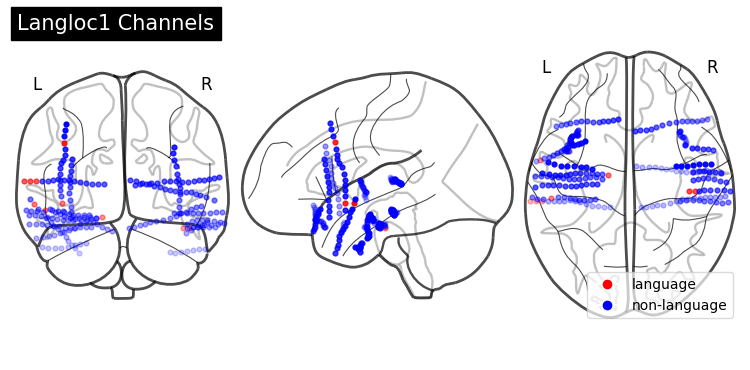

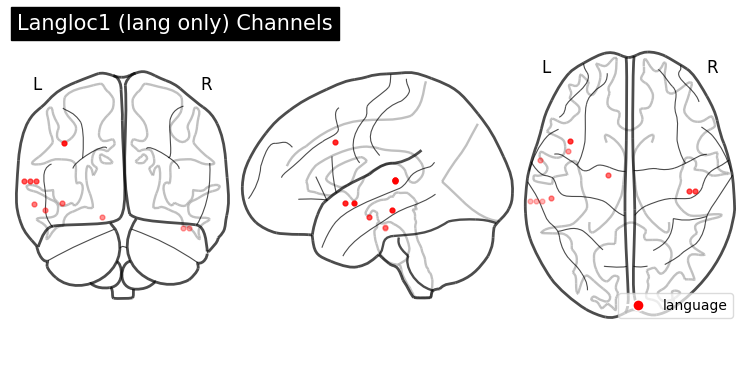

In [29]:
plot_glass_brain_masks(coordinates, 
                       [is_language_responsive_1,~is_language_responsive_1], 
                       ["red","blue"], 
                       ["language","non-language"],
                       s=12,
                       title="Langloc1 Channels")
plot_glass_brain_masks(coordinates, 
                       [is_language_responsive_1], 
                       ["red"], 
                       ["language"],
                       s=12,
                       title="Langloc1 (lang only) Channels")

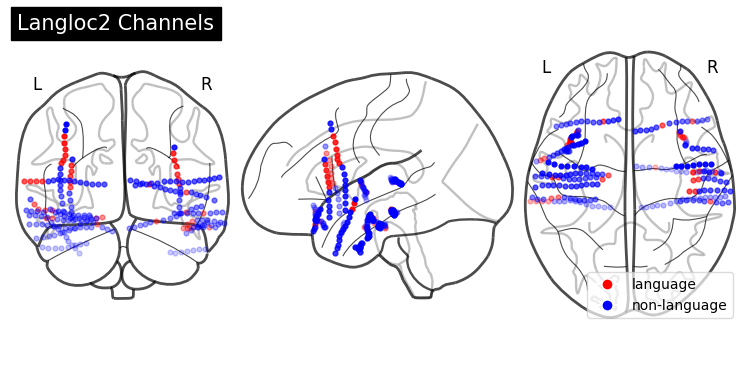

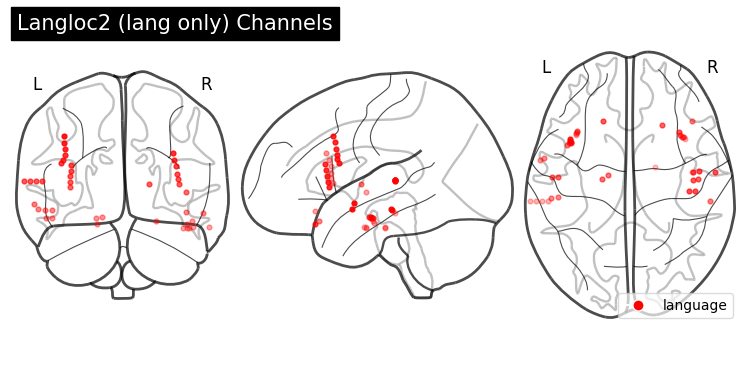

In [30]:
plot_glass_brain_masks(coordinates, 
                       [is_language_responsive_2,~is_language_responsive_2], 
                       ["red","blue"], 
                       ["language","non-language"],
                       s=12,
                       title="Langloc2 Channels")
plot_glass_brain_masks(coordinates, 
                       [is_language_responsive_2], 
                       ["red"], 
                       ["language"],
                       s=12,
                       title="Langloc2 (lang only) Channels")

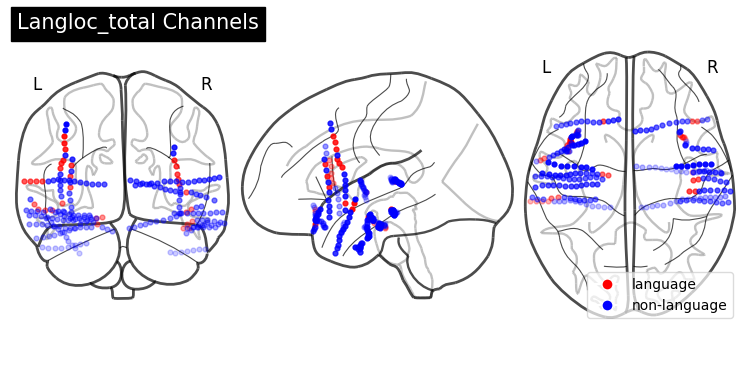

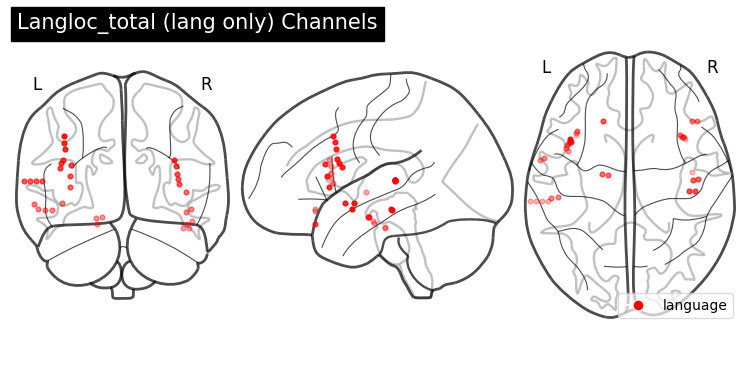

In [41]:
plot_glass_brain_masks(coordinates, 
                       [is_language_responsive_t,~is_language_responsive_t], 
                       ["red","blue"], 
                       ["language","non-language"],
                       s=12,
                       title="Langloc_total Channels")
plot_glass_brain_masks(coordinates, 
                       [is_language_responsive_t], 
                       ["red"], 
                       ["language"],
                       s=12,
                       title="Langloc_total (lang only) Channels")

## Reliability Analysis

### Reliability Matrix
This is a matrix of (channels, trials/2, n_samples) dimensionality since there are 2 conditions

In [42]:
### Reliability Analysis
import numpy as np
from collections import deque

def build_greedy_reliability_matrix(
    trials,
    envelope_data,
    langloc_dict,
):
    """
    Build reliability matrix of concatenated sentence/non-word trial pairs.

    Output shape:
        (n_channels, n_concat_trials, 2 * min_condition_samples)

    Each paired sample is:
        [sentence_trial_clipped, nonword_trial_clipped]

    Matching is greedy in trial order: each trial is paired with the earliest
    previously-unmatched trial of the opposite condition.

    Parameters
    ----------
    langloc1_trials : list of dict
        Trial dictionaries.
    envelope_data : np.ndarray, shape (n_channels, n_samples)
        Neural data.
    langloc_dict : dict
        Must contain keys "sentence" and "non_word".

    Returns
    -------
    reliability_matrix : np.ndarray
        Shape (n_channels, n_pairs, 2 * min_condition_samples)
    pair_indices : list of tuple
        List of matched trial index pairs as (sentence_trial_idx, nonword_trial_idx)
    min_condition_samples : int
        Minimum clipped sample count per single trial condition
    """

    n_channels = envelope_data.shape[0]

    sentence_code = langloc_dict["sentence"]
    nonword_code = langloc_dict["non_word"]

    # -----------------------------
    # Step 1: extract full trial time series per trial
    # -----------------------------
    trial_data = []
    trial_labels = []

    for t, trial in enumerate(trials):
        bounds = trial["word_bounds"]

        if len(bounds) == 0:
            continue

        start_sample = bounds[0][0]
        end_sample = bounds[-1][1]

        if end_sample <= start_sample:
            continue

        data = envelope_data[:, start_sample:end_sample]  # (n_channels, trial_samples)

        if data.shape[1] == 0:
            continue

        code0 = trial["word_codes"][0]
        if code0 == sentence_code:
            label = "sentence"
        elif code0 == nonword_code:
            label = "nonword"
        else:
            continue

        trial_data.append(data)
        trial_labels.append(label)

    # -----------------------------
    # Step 2: greedy matching
    # -----------------------------
    waiting_sent = deque()
    waiting_non = deque()
    pair_indices_local = []

    for i, label in enumerate(trial_labels):
        if label == "sentence":
            if waiting_non:
                j = waiting_non.popleft()
                pair_indices_local.append((i, j))  # (sentence, nonword)
            else:
                waiting_sent.append(i)

        elif label == "nonword":
            if waiting_sent:
                j = waiting_sent.popleft()
                pair_indices_local.append((j, i))  # (sentence, nonword)
            else:
                waiting_non.append(i)

    if len(pair_indices_local) == 0:
        raise ValueError("No sentence/non-word trial pairs could be formed.")

    # -----------------------------
    # Step 3: find minimum usable trial length across all matched trials
    # -----------------------------
    lengths = []
    for s_idx, n_idx in pair_indices_local:
        lengths.append(trial_data[s_idx].shape[1])
        lengths.append(trial_data[n_idx].shape[1])

    min_condition_samples = min(lengths)

    if min_condition_samples <= 0:
        raise ValueError("Minimum condition sample length is not positive.")

    # -----------------------------
    # Step 4: build reliability matrix
    # -----------------------------
    n_pairs = len(pair_indices_local)
    reliability_matrix = np.zeros(
        (n_channels, n_pairs, 2 * min_condition_samples),
        dtype=envelope_data.dtype,
    )

    pair_indices = []

    for p, (s_idx, n_idx) in enumerate(pair_indices_local):
        s_data = trial_data[s_idx][:, :min_condition_samples]
        n_data = trial_data[n_idx][:, :min_condition_samples]

        reliability_matrix[:, p, :min_condition_samples] = s_data
        reliability_matrix[:, p, min_condition_samples:] = n_data

        pair_indices.append((s_idx, n_idx))

    return reliability_matrix, pair_indices, min_condition_samples


In [43]:

reliability_matrix_1, pair_indices_1, min_condition_samples_1 = build_greedy_reliability_matrix(
    trials=langloc1_trials,
    envelope_data=envelope_data,
    langloc_dict=langloc_dict,
)




In [44]:
reliability_matrix_2, pair_indices_2, min_condition_samples_2 = build_greedy_reliability_matrix(
    trials=langloc2_trials,
    envelope_data=envelope_data,
    langloc_dict=langloc_dict,
)

In [45]:
print(reliability_matrix_1.shape)
print(reliability_matrix_2.shape)
print(np.all(reliability_matrix_1 == reliability_matrix_2))
langloc1_trials[0]["word_bounds"][0]
langloc2_trials[0]["word_bounds"][0]

envelope_data[0][langloc2_trials[0]["word_bounds"][0][0]]-envelope_data[0][langloc1_trials[0]["word_bounds"][0][0]]

(227, 24, 790)
(227, 24, 790)
False


np.float64(-0.0049100518226623535)

### Split Half Reliability
Estimating reliability as the correlation between odd and even trials, significance estimated using a bootstrap permuation test

In [46]:
import numpy as np
from scipy.stats import pearsonr

def split_half_reliability(reliability_matrix):
    
    n_channels, n_trials, n_samples = reliability_matrix.shape
    
    odd_trials = reliability_matrix[:, ::2, :]
    even_trials = reliability_matrix[:, 1::2, :]
    
    # equalize if odd number of trials
    n_pairs = min(odd_trials.shape[1], even_trials.shape[1])
    
    odd_trials = odd_trials[:, :n_pairs, :]
    even_trials = even_trials[:, :n_pairs, :]
    
    # average across trials
    odd_mean = odd_trials.mean(axis=1)
    even_mean = even_trials.mean(axis=1)
    
    split_corr = np.zeros(n_channels)
    
    for c in range(n_channels):
        split_corr[c] = pearsonr(odd_mean[c], even_mean[c])[0]
    
    return split_corr

def bootstrap_language_significance(
    lang_corrs,
    nonlang_corrs,
    n_boot=10000,
    seed=0,
):
    """
    Test whether language channel mean reliability is significantly higher
    than expected by chance, using non-language channels as the null pool.

    Parameters
    ----------
    lang_corrs : np.ndarray, shape (n_language_channels,)
        Split-half correlations for language channels.
    nonlang_corrs : np.ndarray, shape (n_nonlanguage_channels,)
        Split-half correlations for non-language channels (null pool).
    n_boot : int
        Number of bootstrap samples.
    seed : int

    Returns
    -------
    dict with keys:
        observed_mean   : float, mean reliability of language channels
        null_mean       : float, mean of null distribution
        null_lower      : float, 2.5th percentile of null
        null_upper      : float, 97.5th percentile of null
        p_value         : float, one-tailed p-value
    """
    rng = np.random.default_rng(seed)
    n_lang = len(lang_corrs)
    n_nonlang = len(nonlang_corrs)

    if n_lang > n_nonlang:
        raise ValueError(
            f"Cannot sample {n_lang} channels without replacement "
            f"from {n_nonlang} non-language channels."
        )

    observed_mean = lang_corrs.mean()

    # build null distribution
    null_means = np.zeros(n_boot)
    for b in range(n_boot):
        sample = rng.choice(nonlang_corrs, size=n_lang, replace=False)
        null_means[b] = sample.mean()

    p_value = (null_means >= observed_mean).mean()

    return {
        "observed_mean": observed_mean,
        "null_mean":     null_means.mean(),
        "null_lower":    np.percentile(null_means, 2.5),
        "null_upper":    np.percentile(null_means, 97.5),
        "p_value":       p_value,
    }

In [47]:

lang1_corrs    = split_half_reliability(reliability_matrix_2[is_language_responsive_1])
nonlang1_corrs = split_half_reliability(reliability_matrix_2[~is_language_responsive_1])

results1 = bootstrap_language_significance(lang1_corrs, nonlang1_corrs)

print(f"observed={results1['observed_mean']:.3f}, p={results1['p_value']:.4f}")
print(f"null={results1['null_mean']:.3f}, bounds=[{results1['null_lower']:.3f},{results1['null_upper']:.3f}]")

lang2_corrs    = split_half_reliability(reliability_matrix_1[is_language_responsive_2])
nonlang2_corrs = split_half_reliability(reliability_matrix_1[~is_language_responsive_2])

results2 = bootstrap_language_significance(lang2_corrs, nonlang2_corrs)

print(f"observed={results2['observed_mean']:.3f}, p={results2['p_value']:.4f}")
print(f"null={results2['null_mean']:.3f}, bounds=[{results2['null_lower']:.3f},{results2['null_upper']:.3f}]")


observed=0.182, p=0.0121
null=0.102, bounds=[0.045,0.169]
observed=0.139, p=0.0002
null=0.095, bounds=[0.072,0.119]


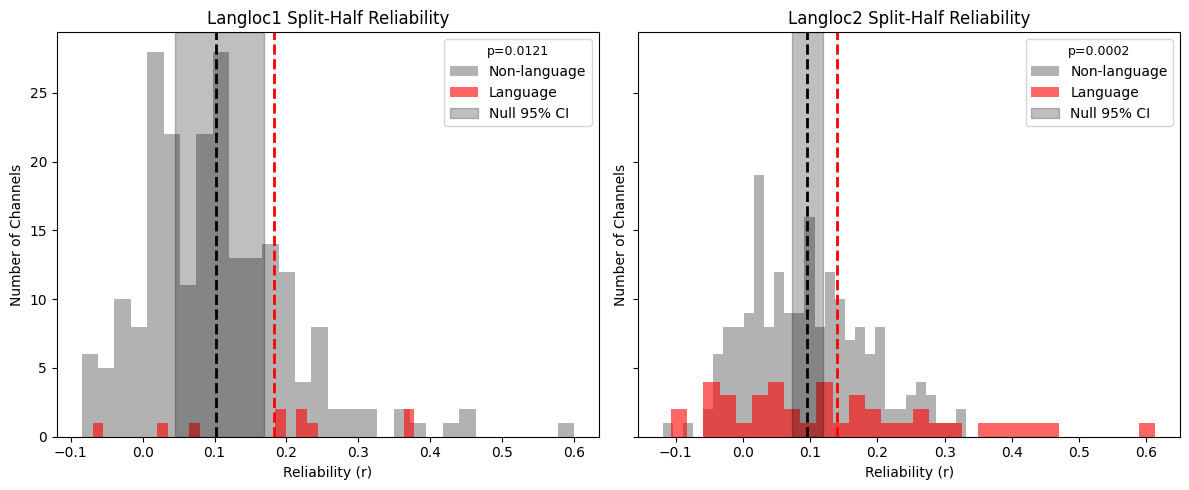

In [48]:

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bins = 30

for ax, lang_corrs, nonlang_corrs, results, title in [
    (axes[0], lang1_corrs, nonlang1_corrs, results1, "Langloc1 Split-Half Reliability"),
    (axes[1], lang2_corrs, nonlang2_corrs, results2, "Langloc2 Split-Half Reliability"),
]:
    lang_r    = lang_corrs
    nonlang_r = nonlang_corrs

    ax.hist(nonlang_r, bins=bins, color="gray", alpha=0.6, label="Non-language")
    ax.hist(lang_r,    bins=bins, color="red",  alpha=0.6, label="Language")

    ax.axvline(nonlang_r.mean(), color="black", linestyle="--", linewidth=2)
    ax.axvline(lang_r.mean(),    color="red",   linestyle="--", linewidth=2)

    ax.axvspan(
        results["null_lower"], results["null_upper"],
        alpha=0.25, color="black", label="Null 95% CI"
    )

    ax.set_title(title)
    ax.set_xlabel("Reliability (r)")
    ax.set_ylabel("Number of Channels")
    ax.legend(
        title=f"p={results['p_value']:.4f}",
        title_fontsize=9
    )

plt.tight_layout()
plt.show()

## Other analyses
### Bar graphs of activity difference

In [77]:
lang_mask_1 = is_language_responsive_1 #language electrodes as determined by langloc1
lang_mask_2 = is_language_responsive_2 #similarly

_,_,n_samples = reliability_matrix_1.shape
n_cond_samples = n_samples//2
#langloc1 trial data for sent and non-word conditions respectively
sent_mat_1, nw_mat_1 = (reliability_matrix_1[:,:,:n_cond_samples],reliability_matrix_1[:,:,n_cond_samples:])
#langloc2 trial data for sent and non-word conditions respectively
sent_mat_2, nw_mat_2 = (reliability_matrix_2[:,:,:n_cond_samples],reliability_matrix_2[:,:,n_cond_samples:])

In [78]:
lang_mask_2

array([ True, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False,  True,  True, False, False, False, False,
       False, False, False, False, False, False,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True,  True,  True,  True,
       False,  True,

In [50]:
sent_1_avg = sent_mat_1.mean(axis=1)
sent_2_avg = sent_mat_2.mean(axis=1)
nw_1_avg = nw_mat_1.mean(axis=1)
nw_2_avg = nw_mat_2.mean(axis=1)

sent_1_avg_mag = sent_1_avg.mean(axis=1)
sent_2_avg_mag = sent_2_avg.mean(axis=1)
nw_1_avg_mag = nw_1_avg.mean(axis=1)
nw_2_avg_mag = nw_2_avg.mean(axis=1)

In [51]:
import numpy as np
import matplotlib.pyplot as plt

def plot_masked_bars(
    sent_vals,
    nw_vals,
    mask,
    title="Sentence vs Non-word by Mask",
    group_labels=("Language", "Non-language"),
    plot_points=True,
    jitter=0.0,
    point_alpha=0.6,
    point_size=18,
):
    sent_vals = np.asarray(sent_vals)
    nw_vals = np.asarray(nw_vals)
    mask = np.asarray(mask).astype(bool)

    group1 = mask
    group2 = ~mask

    sent_g1, nw_g1 = sent_vals[group1], nw_vals[group1]
    sent_g2, nw_g2 = sent_vals[group2], nw_vals[group2]

    def mean_se(x):
        if len(x) <= 1:
            return np.mean(x), 0.0
        return np.mean(x), np.std(x, ddof=1) / np.sqrt(len(x))

    means = np.array([
        [mean_se(sent_g1)[0], mean_se(nw_g1)[0]],
        [mean_se(sent_g2)[0], mean_se(nw_g2)[0]],
    ])
    ses = np.array([
        [mean_se(sent_g1)[1], mean_se(nw_g1)[1]],
        [mean_se(sent_g2)[1], mean_se(nw_g2)[1]],
    ])

    x = np.arange(2)
    width = 0.34
    sent_pos = x - width / 2
    nw_pos = x + width / 2

    fig, ax = plt.subplots(figsize=(8, 6))

    # --- DARK COLORS (no transparency) ---
    sent_color = "#1f3a8a"   # dark blue
    nw_color   = "#b91c1c"   # dark red

    # Bars
    ax.bar(sent_pos, means[:, 0], width=width, color=sent_color, label="Sentence", zorder=1)
    ax.bar(nw_pos,   means[:, 1], width=width, color=nw_color,   label="Non-word", zorder=1)

    # Points + dashed lines
    if plot_points:
        rng = np.random.default_rng(0)

        def draw_group(sent_g, nw_g, idx):
            for i in range(len(sent_g)):
                j1 = rng.uniform(-jitter, jitter) if jitter > 0 else 0
                j2 = rng.uniform(-jitter, jitter) if jitter > 0 else 0

                x1 = sent_pos[idx] + j1
                x2 = nw_pos[idx] + j2

                y1 = sent_g[i]
                y2 = nw_g[i]

                ax.plot(
                    [x1, x2],
                    [y1, y2],
                    linestyle="--",
                    color="gray",
                    linewidth=0.8,
                    alpha=0.5,
                    zorder=2,
                )

                ax.scatter(
                    [x1, x2],
                    [y1, y2],
                    color="gray",
                    alpha=point_alpha,
                    s=point_size,
                    zorder=3,
                )

        draw_group(sent_g1, nw_g1, 0)
        draw_group(sent_g2, nw_g2, 1)

    # --- SE bars ON TOP ---
    ax.errorbar(
        sent_pos,
        means[:, 0],
        yerr=ses[:, 0],
        fmt="none",
        ecolor="black",
        elinewidth=1.5,
        capsize=5,
        zorder=5,
    )
    ax.errorbar(
        nw_pos,
        means[:, 1],
        yerr=ses[:, 1],
        fmt="none",
        ecolor="black",
        elinewidth=1.5,
        capsize=5,
        zorder=5,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(group_labels)
    ax.set_ylabel("Average magnitude")
    ax.set_xlabel("Mask condition")
    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

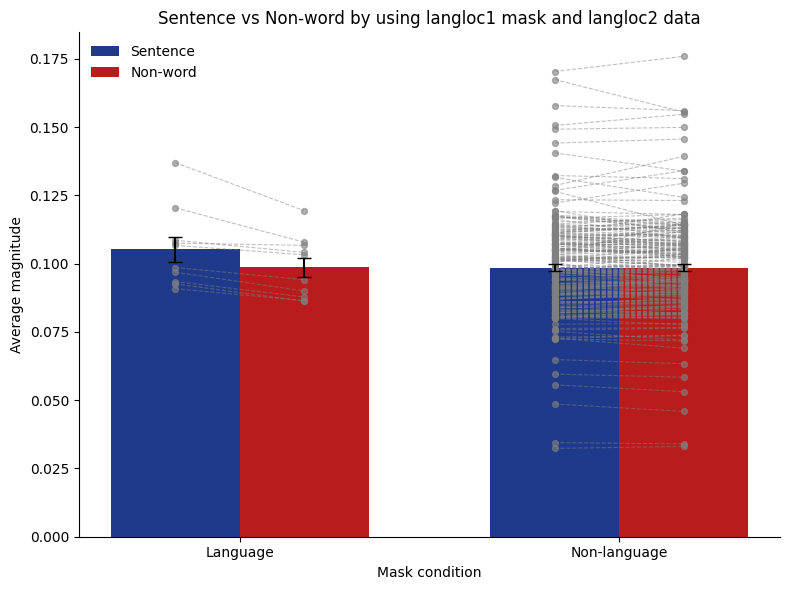

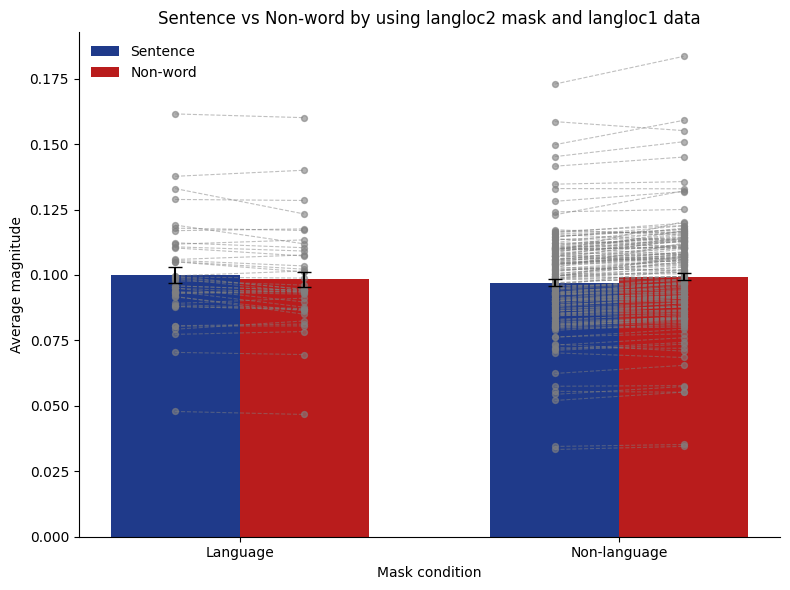

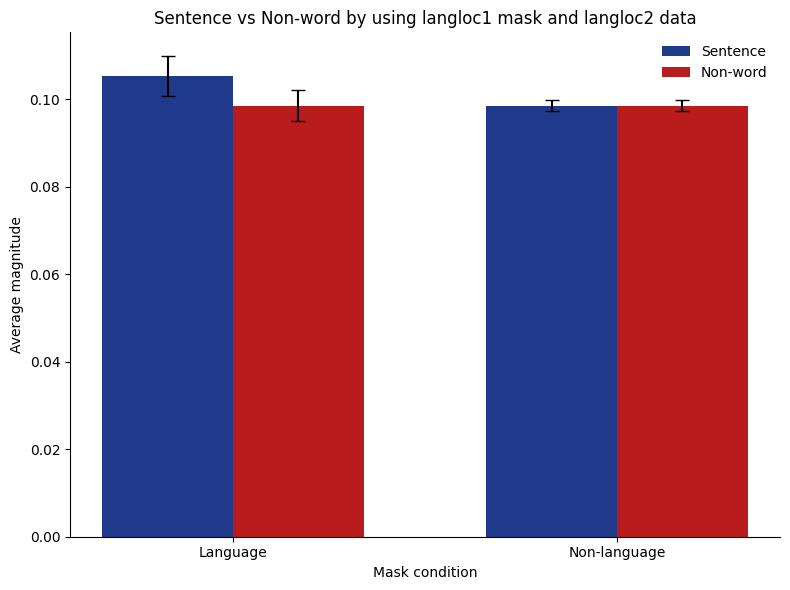

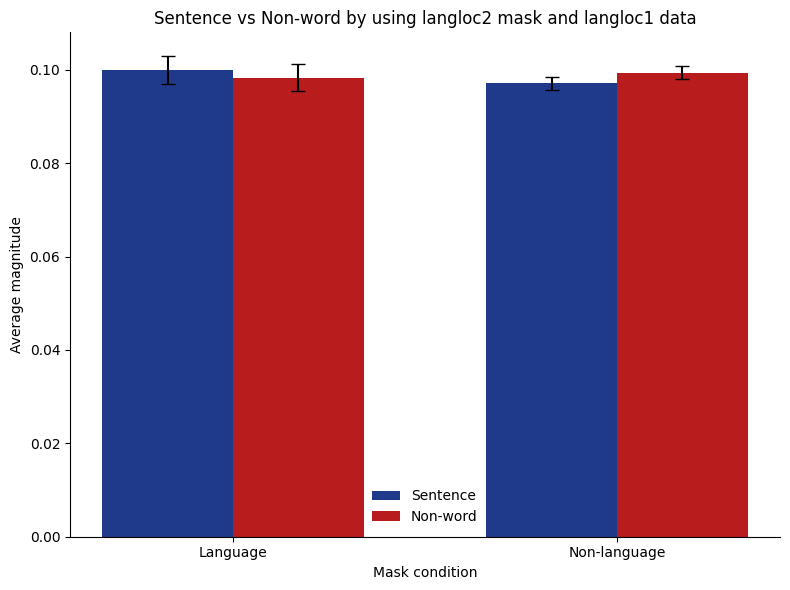

In [52]:
plot_masked_bars(
    sent_2_avg_mag,
    nw_2_avg_mag,
    lang_mask_1,
    plot_points=True,
    title="Sentence vs Non-word by using langloc1 mask and langloc2 data"
)

plot_masked_bars(
    sent_1_avg_mag,
    nw_1_avg_mag,
    lang_mask_2,
    plot_points=True,
    title="Sentence vs Non-word by using langloc2 mask and langloc1 data"
)

plot_masked_bars(
    sent_2_avg_mag,
    nw_2_avg_mag,
    lang_mask_1,
    plot_points=False,
    title="Sentence vs Non-word by using langloc1 mask and langloc2 data"
)

plot_masked_bars(
    sent_1_avg_mag,
    nw_1_avg_mag,
    lang_mask_2,
    plot_points=False,
    title="Sentence vs Non-word by using langloc2 mask and langloc1 data"
)

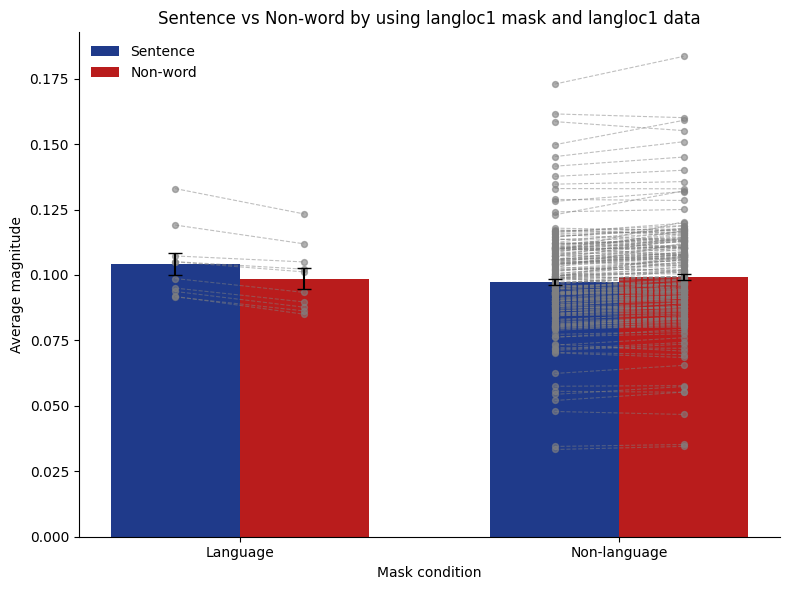

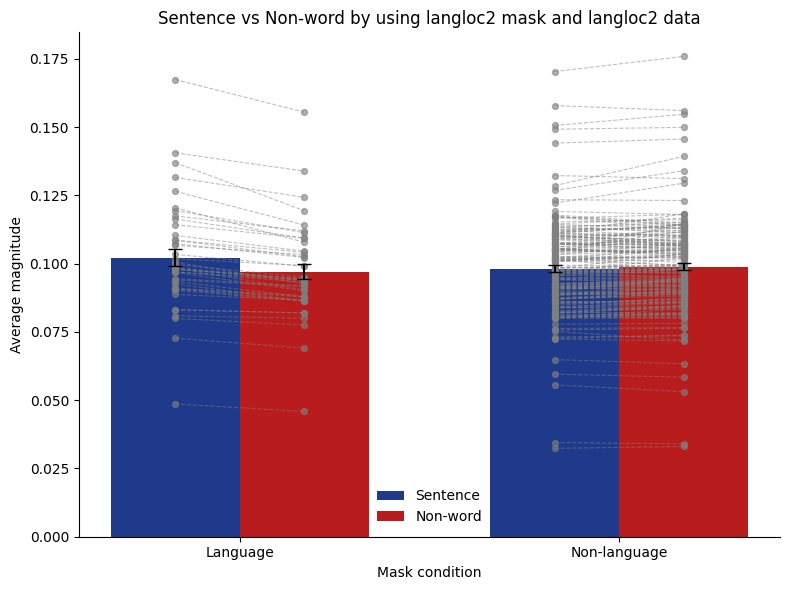

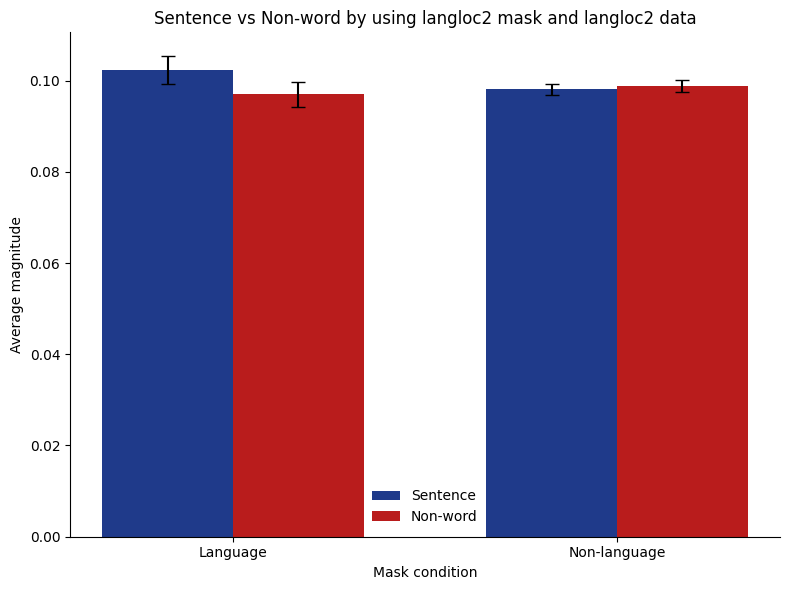

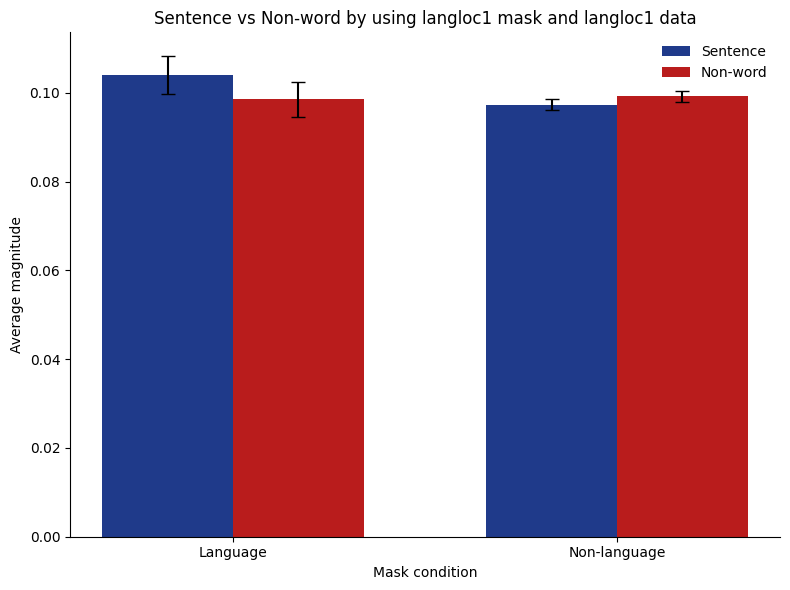

In [53]:
plot_masked_bars(
    sent_1_avg_mag,
    nw_1_avg_mag,
    lang_mask_1,
    plot_points=True,
    title="Sentence vs Non-word by using langloc1 mask and langloc1 data"
)

plot_masked_bars(
    sent_2_avg_mag,
    nw_2_avg_mag,
    lang_mask_2,
    plot_points=True,
    title="Sentence vs Non-word by using langloc2 mask and langloc2 data"
)

plot_masked_bars(
    sent_2_avg_mag,
    nw_2_avg_mag,
    lang_mask_2,
    plot_points=False,
    title="Sentence vs Non-word by using langloc2 mask and langloc2 data"
)

plot_masked_bars(
    sent_1_avg_mag,
    nw_1_avg_mag,
    lang_mask_1,
    plot_points=False,
    title="Sentence vs Non-word by using langloc1 mask and langloc1 data"
)

In [54]:
n_electrodes, _ = sent_1_avg.shape

# --- Language electrodes ---
lang_2_sent_1_electrode_avg = sent_1_avg[lang_mask_2].mean(axis=0)
lang_1_sent_2_electrode_avg = sent_2_avg[lang_mask_1].mean(axis=0)
lang_2_nw_1_electrode_avg = nw_1_avg[lang_mask_2].mean(axis=0)
lang_1_nw_2_electrode_avg = nw_2_avg[lang_mask_1].mean(axis=0)

# --- Non-language electrodes ---
nonlang_2_sent_1_electrode_avg = sent_1_avg[~lang_mask_2].mean(axis=0)
nonlang_1_sent_2_electrode_avg = sent_2_avg[~lang_mask_1].mean(axis=0)
nonlang_2_nw_1_electrode_avg = nw_1_avg[~lang_mask_2].mean(axis=0)
nonlang_1_nw_2_electrode_avg = nw_2_avg[~lang_mask_1].mean(axis=0)

# --- Language electrodes ---
lang_2_sent_1_electrode_SE = sent_1_avg[lang_mask_2].std(axis=0, ddof=1) / np.sqrt(n_electrodes)
lang_1_sent_2_electrode_SE = sent_2_avg[lang_mask_1].std(axis=0, ddof=1) / np.sqrt(n_electrodes)
lang_2_nw_1_electrode_SE   = nw_1_avg[lang_mask_2].std(axis=0, ddof=1)   / np.sqrt(n_electrodes)
lang_1_nw_2_electrode_SE   = nw_2_avg[lang_mask_1].std(axis=0, ddof=1)   / np.sqrt(n_electrodes)

# --- Non-language electrodes ---
nonlang_2_sent_1_electrode_SE = sent_1_avg[~lang_mask_2].std(axis=0, ddof=1) / np.sqrt(n_electrodes)
nonlang_1_sent_2_electrode_SE = sent_2_avg[~lang_mask_1].std(axis=0, ddof=1) / np.sqrt(n_electrodes)
nonlang_2_nw_1_electrode_SE   = nw_1_avg[~lang_mask_2].std(axis=0, ddof=1)   / np.sqrt(n_electrodes)
nonlang_1_nw_2_electrode_SE   = nw_2_avg[~lang_mask_1].std(axis=0, ddof=1)   / np.sqrt(n_electrodes)


In [80]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sent_nw_mask(sent_avg, nw_avg, mask, frequency, title=None, word_onsets=None):
    n_electrodes = sent_avg.shape[0]

    def mean_se(arr, m):
        subset = arr[m]
        mean = subset.mean(axis=0)
        se = subset.std(axis=0, ddof=1) / np.sqrt(subset.shape[0])
        return mean, se, subset

    def add_mean_ci_lines(ax, subset, color):
        """
        Adds horizontal mean line and 95% CI lines based on the overall
        average response across electrodes and time.
        """
        electrode_means = subset.mean(axis=1)

        overall_mean = electrode_means.mean()
        se = electrode_means.std(ddof=1) / np.sqrt(len(electrode_means))
        ci = 1.96 * se

        ax.axhline(overall_mean, color=color, linestyle="-", linewidth=1.5, alpha=0.8)
        ax.axhline(overall_mean + ci, color=color, linestyle="--", linewidth=1.2, alpha=0.8)
        ax.axhline(overall_mean - ci, color=color, linestyle="--", linewidth=1.2, alpha=0.8)

    sent_lang_mean, sent_lang_se, sent_lang_subset = mean_se(sent_avg, mask)
    sent_non_mean,  sent_non_se,  sent_non_subset  = mean_se(sent_avg, ~mask)

    nw_lang_mean, nw_lang_se, nw_lang_subset = mean_se(nw_avg, mask)
    nw_non_mean,  nw_non_se,  nw_non_subset  = mean_se(nw_avg, ~mask)

    n_points = sent_avg.shape[1]
    x = np.arange(n_points) / frequency

    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

    c_lang_sent = "blue"
    c_lang_nw   = "purple"
    c_non_sent  = "red"
    c_non_nw    = "gray"

    if word_onsets is not None:
        word_onsets = np.asarray(word_onsets) / frequency
        first_ax = axes[0, 0]
        for ax in axes.ravel():
            for i, onset in enumerate(word_onsets):
                ax.axvline(
                    onset,
                    color="black",
                    linestyle="--",
                    alpha=0.5,
                    linewidth=1.0,
                    zorder=0,
                    label="Word onset" if ax is first_ax and i == 0 else None,
                )

    # Language — Sentence
    ax = axes[0, 0]
    ax.fill_between(x, sent_lang_mean - sent_lang_se, sent_lang_mean + sent_lang_se,
                    color=c_lang_sent, alpha=0.2, zorder=1)
    ax.plot(x, sent_lang_mean, color=c_lang_sent, linewidth=2, zorder=2)
    add_mean_ci_lines(ax, sent_lang_subset, c_lang_sent)
    ax.set_title("Language — Sentence")
    ax.set_ylabel("Average response")

    # Language — Non-word
    ax = axes[0, 1]
    ax.fill_between(x, nw_lang_mean - nw_lang_se, nw_lang_mean + nw_lang_se,
                    color=c_lang_nw, alpha=0.2, zorder=1)
    ax.plot(x, nw_lang_mean, color=c_lang_nw, linewidth=2, zorder=2)
    add_mean_ci_lines(ax, nw_lang_subset, c_lang_nw)
    ax.set_title("Language — Non-word")

    # Non-language — Sentence
    ax = axes[1, 0]
    ax.fill_between(x, sent_non_mean - sent_non_se, sent_non_mean + sent_non_se,
                    color=c_non_sent, alpha=0.2, zorder=1)
    ax.plot(x, sent_non_mean, color=c_non_sent, linewidth=2, zorder=2)
    add_mean_ci_lines(ax, sent_non_subset, c_non_sent)
    ax.set_title("Non-language — Sentence")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Average response")

    # Non-language — Non-word
    ax = axes[1, 1]
    ax.fill_between(x, nw_non_mean - nw_non_se, nw_non_mean + nw_non_se,
                    color=c_non_nw, alpha=0.25, zorder=1)
    ax.plot(x, nw_non_mean, color=c_non_nw, linewidth=2, zorder=2)
    add_mean_ci_lines(ax, nw_non_subset, c_non_nw)
    ax.set_title("Non-language — Non-word")
    ax.set_xlabel("Time (s)")

    for ax in axes.ravel():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    if word_onsets is not None:
        axes[0, 0].legend(frameon=True, facecolor="white", edgecolor="black")

    if title is not None:
        fig.suptitle(title, fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        plt.tight_layout()

    plt.show()

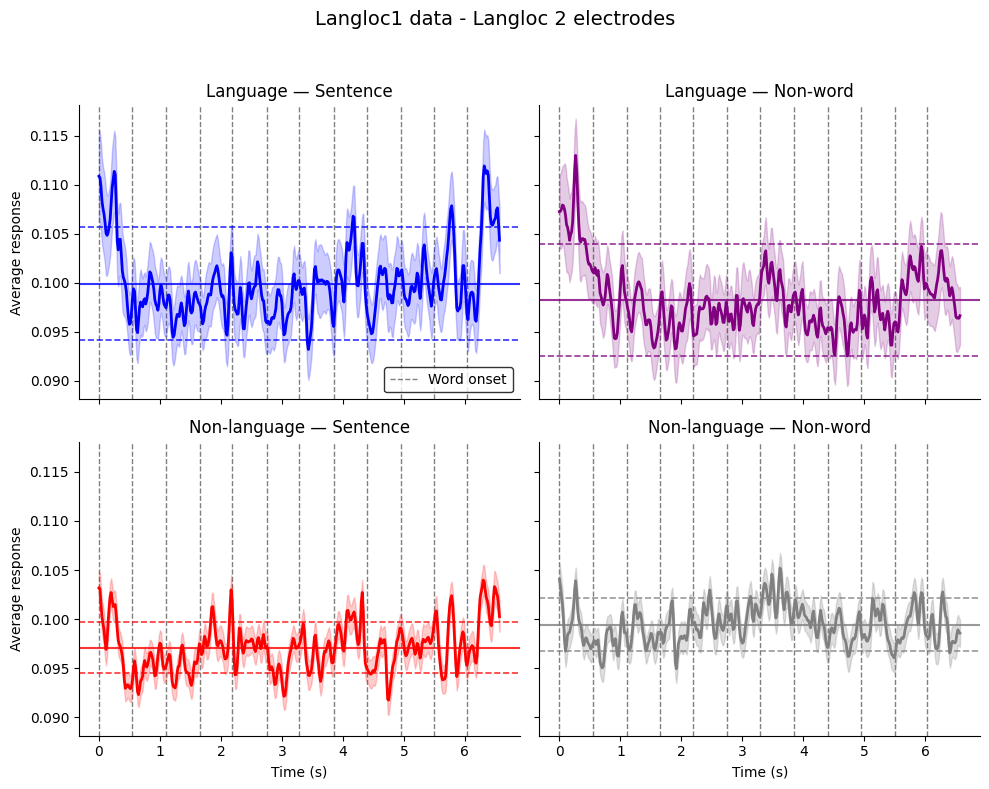

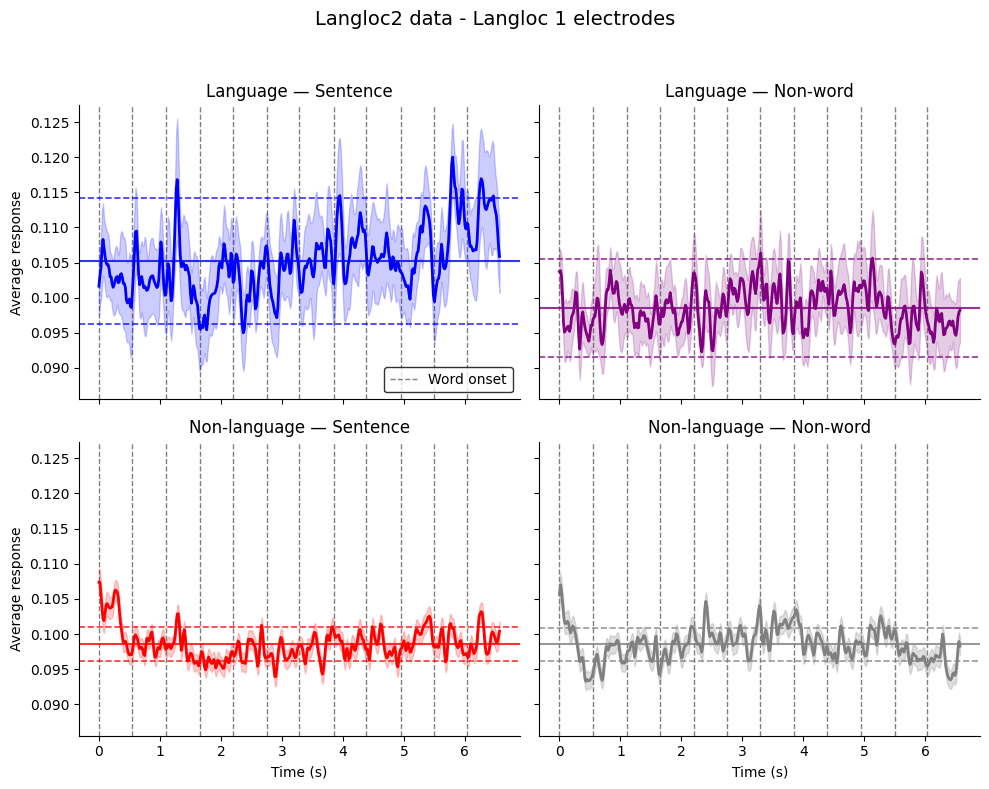

In [86]:
plot_sent_nw_mask(
    sent_1_avg,
    nw_1_avg,
    lang_mask_2,
    frequency=60,
    title="Langloc1 data - Langloc 2 electrodes",
    word_onsets=langloc1_word_starts
)

plot_sent_nw_mask(
    sent_2_avg,
    nw_2_avg,
    lang_mask_1,
    frequency=60,
    title="Langloc2 data - Langloc 1 electrodes",
    word_onsets=langloc2_word_starts
)

(227, 33)

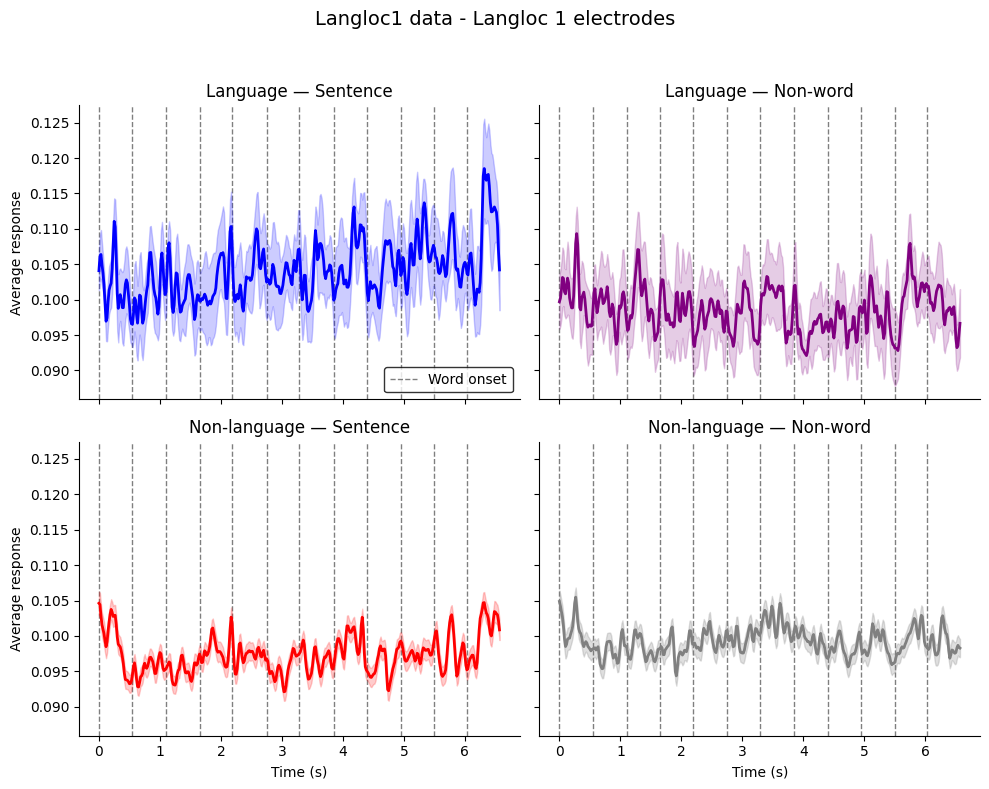

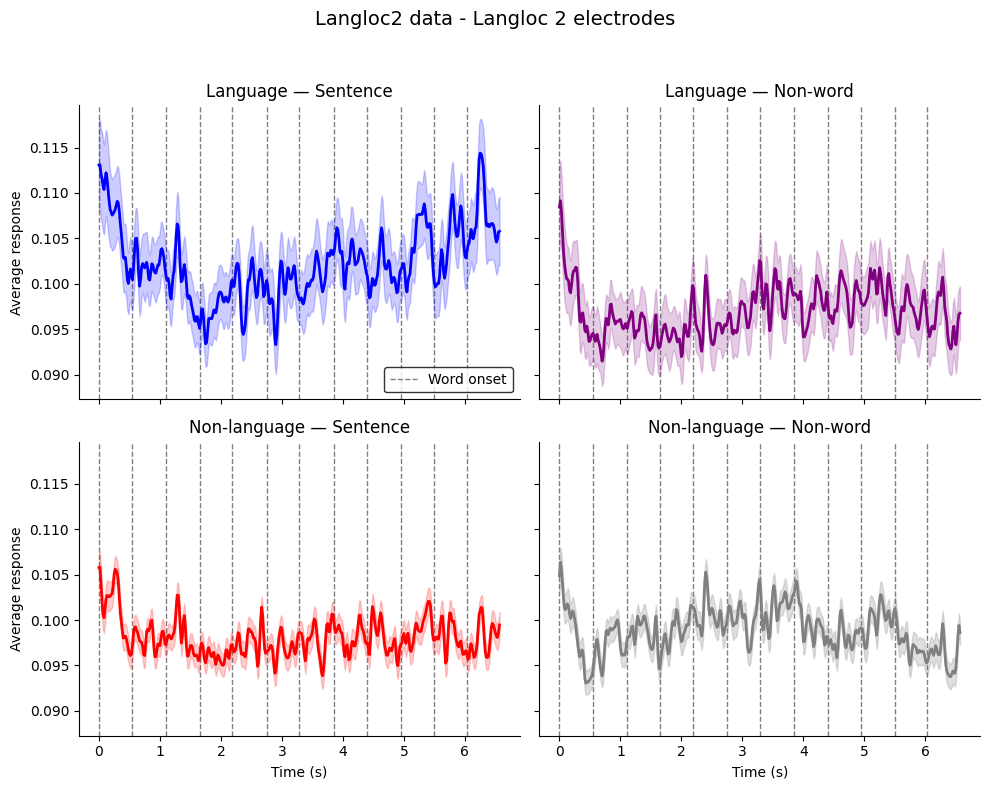

In [57]:
plot_sent_nw_mask(
    sent_1_avg,
    nw_1_avg,
    lang_mask_1,
    frequency=60,
    title="Langloc1 data - Langloc 1 electrodes",
    word_onsets=langloc1_word_starts
)

plot_sent_nw_mask(
    sent_2_avg,
    nw_2_avg,
    lang_mask_2,
    frequency=60,
    title="Langloc2 data - Langloc 2 electrodes",
    word_onsets=langloc2_word_starts
)

### Exclude first word

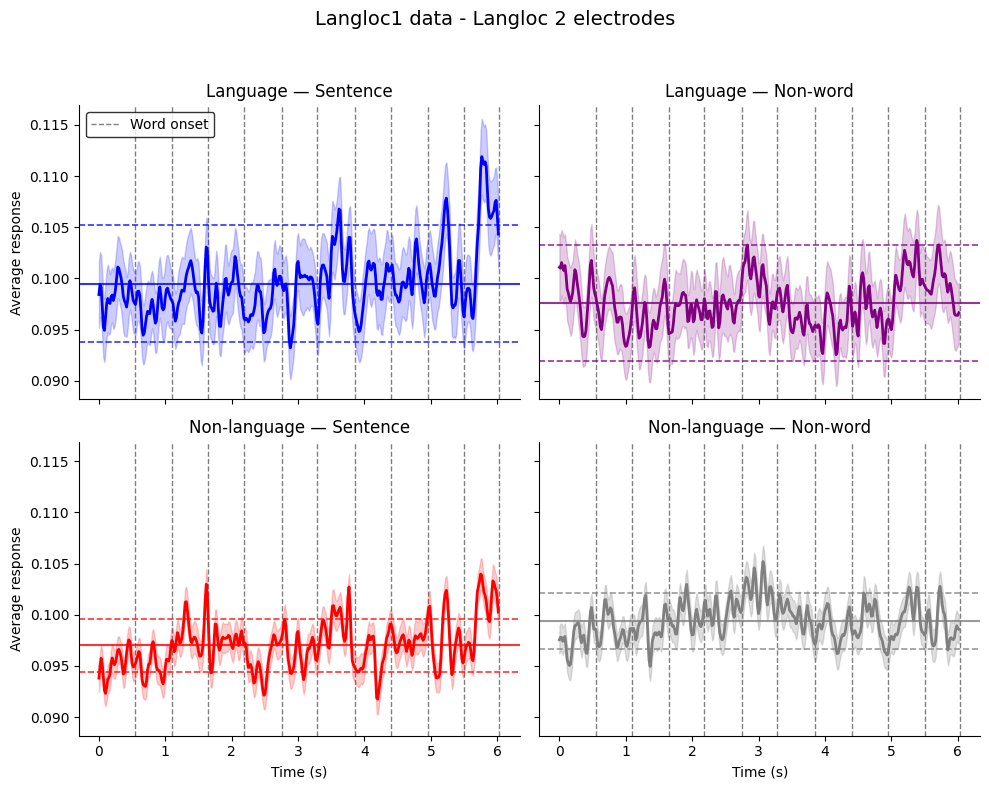

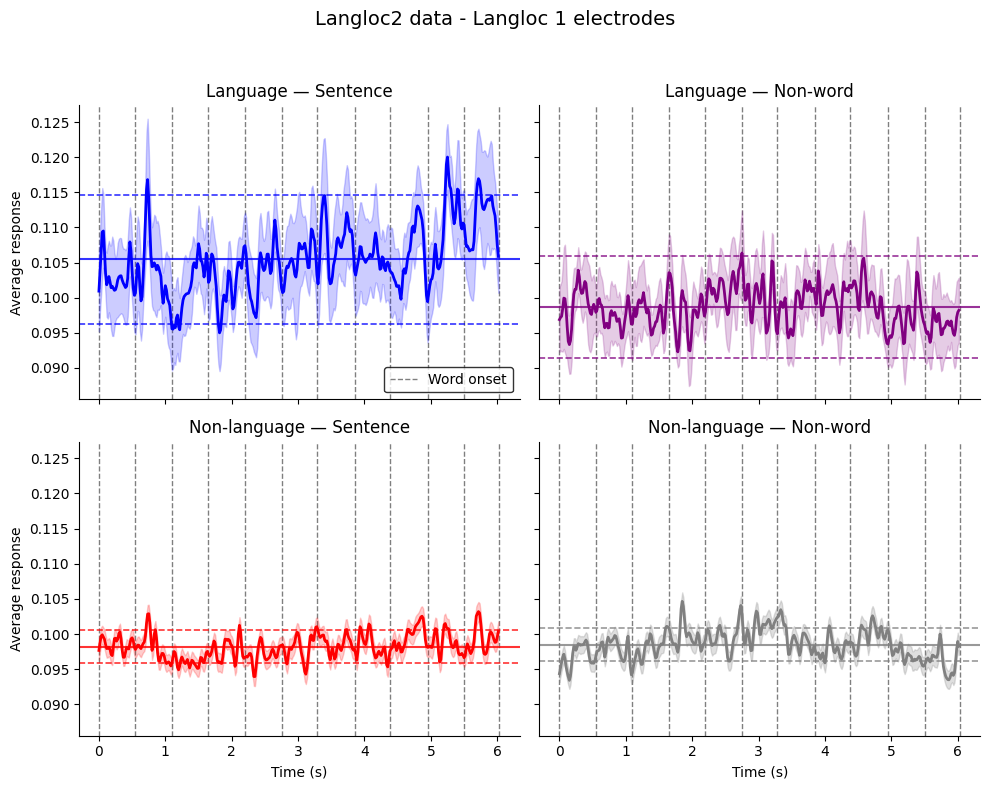

In [93]:
plot_sent_nw_mask(
    sent_1_avg[:,langloc1_word_starts[1]:],
    nw_1_avg[:,langloc1_word_starts[1]:],
    lang_mask_2,
    frequency=60,
    title="Langloc1 data - Langloc 2 electrodes",
    word_onsets=langloc1_word_starts[1:]
)

plot_sent_nw_mask(
    sent_2_avg[:,langloc2_word_starts[1]:],
    nw_2_avg[:,langloc2_word_starts[1]:],
    lang_mask_1,
    frequency=60,
    title="Langloc2 data - Langloc 1 electrodes",
    word_onsets=langloc2_word_starts
)

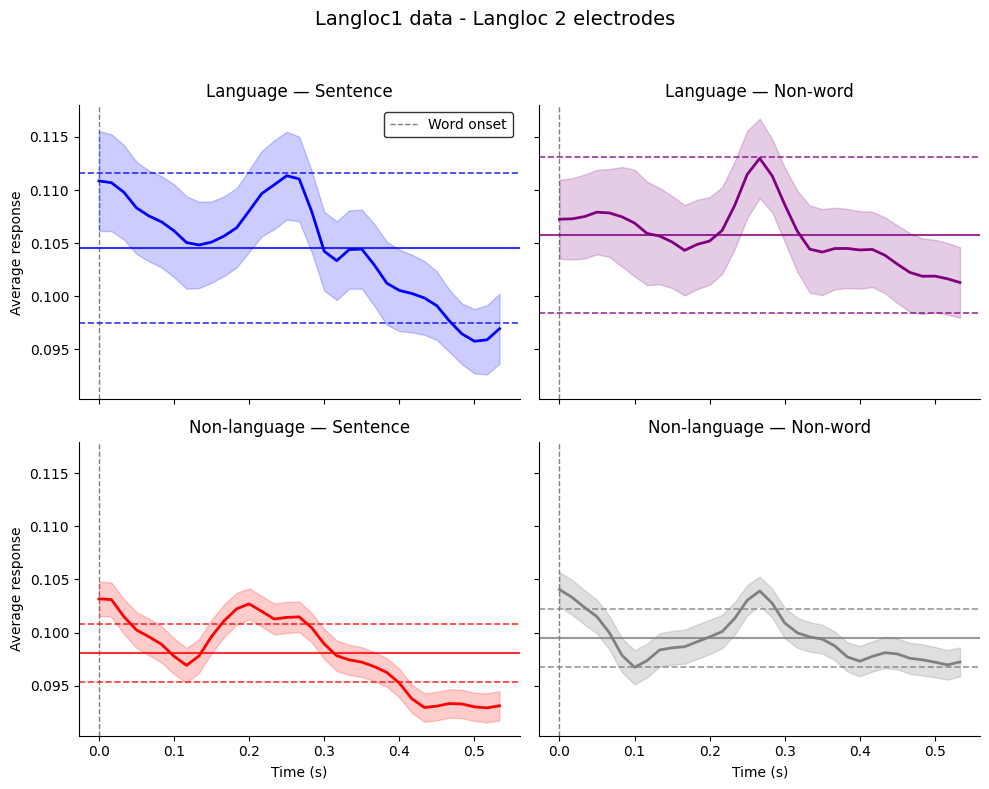

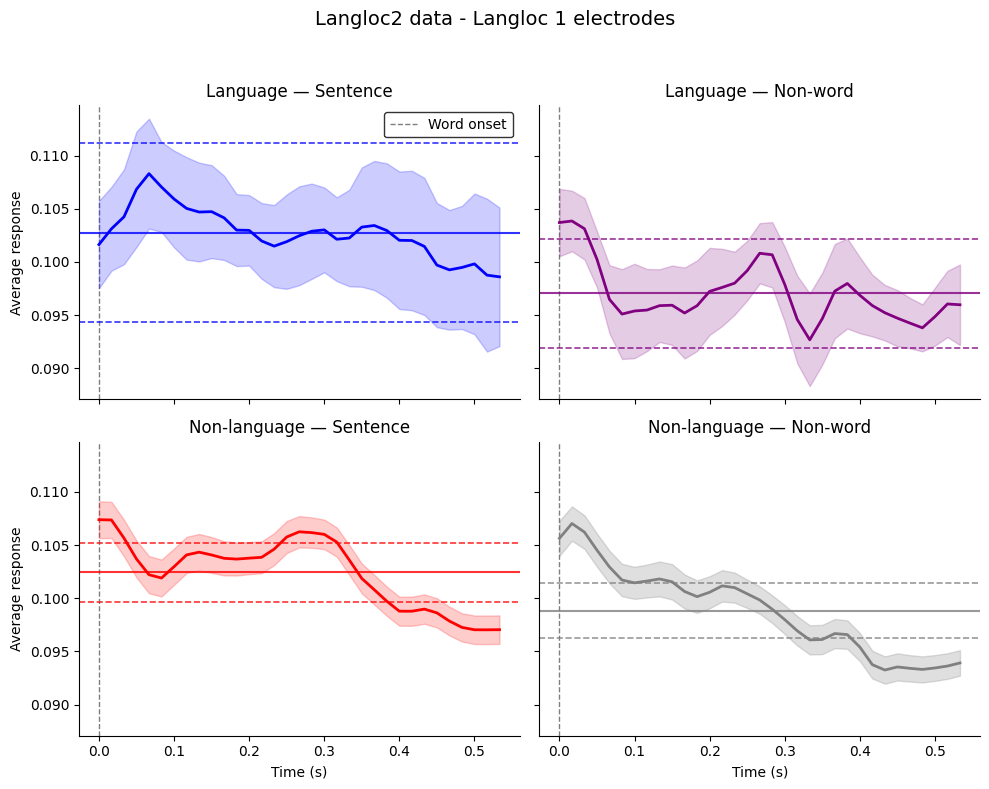

In [95]:
plot_sent_nw_mask(
    sent_1_avg[:,:langloc1_word_starts[1]],
    nw_1_avg[:,:langloc1_word_starts[1]],
    lang_mask_2,
    frequency=60,
    title="Langloc1 data - Langloc 2 electrodes",
    word_onsets=langloc1_word_starts[:1]
)

plot_sent_nw_mask(
    sent_2_avg[:,:langloc2_word_starts[1]],
    nw_2_avg[:,:langloc2_word_starts[1]],
    lang_mask_1,
    frequency=60,
    title="Langloc2 data - Langloc 1 electrodes",
    word_onsets=langloc2_word_starts[:1]
)

### Analysis of trial onset

In [97]:
import numpy as np

def row_slopes(data):
    """
    Compute slope of best-fit line for each row.

    data: (n_rows, n_time)

    Returns:
        slopes: (n_rows,)
    """
    data = np.asarray(data)

    n_rows, n_time = data.shape
    x = np.arange(n_time)

    # center x once
    x_mean = x.mean()
    x_centered = x - x_mean

    # compute slopes
    numerator = np.sum(x_centered * data, axis=1)
    denominator = np.sum(x_centered ** 2)

    slopes = numerator / denominator
    return slopes

In [101]:
import pandas as pd
def load_column_from_csv(filepath: str, column_name: str) -> np.ndarray:
    """
    Load a specific column from a CSV file and return it as a NumPy array.

    Args:
        filepath: Path to the CSV file.
        column_name: Name of the column to extract.

    Returns:
        NumPy array of the column values.
    """
    df = pd.read_csv(filepath)

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found. Available columns: {list(df.columns)}")

    return df[column_name].to_numpy()

In [118]:
csv_path_2 = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/preprocessed/electrodes.csv")
spike_rate = load_column_from_csv(csv_path_2,"spike_rate")
is_bad = np.bool(load_column_from_csv(csv_path_2,"is_bad"))
spike_rate = spike_rate[~is_bad]

(227,)

array([1.88452422, 1.34451435, 0.60613352, 0.87062815, 0.39674194,
       0.29755646, 0.27551524, 0.26449463, 1.24532887, 0.52898925,
       1.33349374, 0.61715413, 0.44082438, 0.70531901, 0.41878316,
       0.59511291, 0.33061828, 0.30857706, 0.27551524, 0.31959767,
       0.31959767, 0.15428853, 0.13224731, 0.20939158, 0.30857706,
       0.2314328 , 0.44082438, 0.31959767, 0.83756632, 0.37470072,
       0.31959767, 0.26449463, 0.22041219, 1.85146239, 0.84858693,
       0.11020609, 0.14326792, 0.2314328 , 1.19022582, 1.96166848,
       0.61715413, 0.57307169, 0.51796864, 0.20939158, 0.90368998,
       0.71633961, 0.34163889, 0.25347402, 0.24245341, 0.27551524,
       0.30857706, 0.83756632, 0.11020609, 0.18735036, 0.11020609,
       0.65021596, 2.36943103, 3.93435758, 5.62051082, 5.2458101 ,
       0.60613352, 0.9367518 , 0.76042205, 0.47388621, 0.36368011,
       1.23430826, 2.6780081 , 2.89842029, 0.77144266, 0.66123657,
       0.6942984 , 0.36368011, 0.06612366, 0.04408244, 0.04408

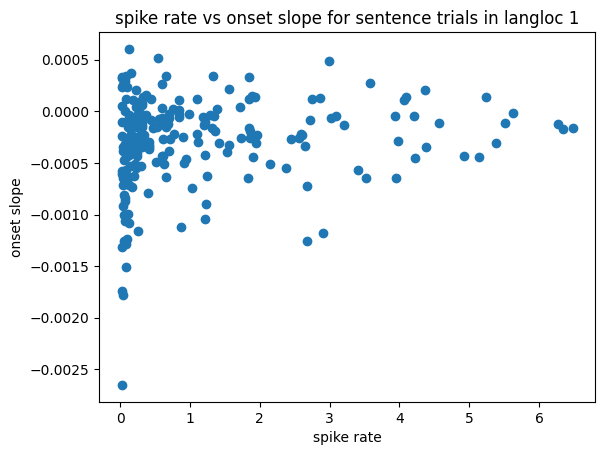

In [125]:
sent_1_avg_slope = row_slopes(sent_1_avg[:,:langloc1_word_starts[1]])
sent_1_avg_slope.shape
plt.figure()
plt.plot(spike_rate,sent_1_avg_slope,'o')
plt.xlabel("spike rate")
plt.ylabel("onset slope")
plt.title("spike rate vs onset slope for sentence trials in langloc 1")

spike_rate

nan


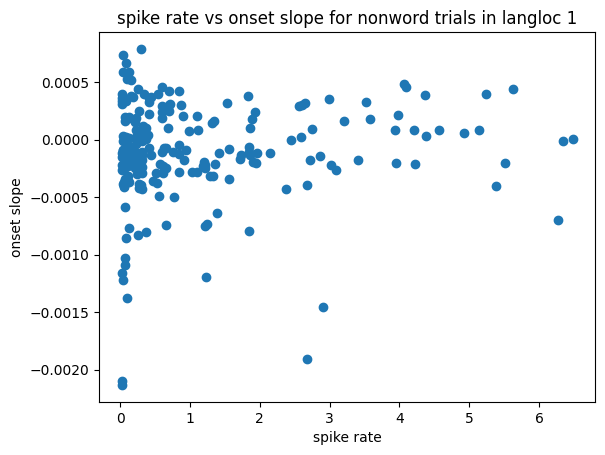

In [122]:
nw_1_avg_slope = row_slopes(nw_1_avg[:,:langloc1_word_starts[1]])
plt.figure()
plt.plot(spike_rate,nw_1_avg_slope,'o')
plt.xlabel("spike rate")
plt.ylabel("onset slope")
plt.title("spike rate vs onset slope for nonword trials in langloc 1")
print(np.corrcoef(spike_rate,sent_1_avg_slope)[0,1])

### Plot indidividuals

In [58]:
import numpy as np
import matplotlib.pyplot as plt

def plot_row_correlation_matrix(data, title="Row-wise Correlation Matrix"):
    """
    data: numpy array of shape (n_rows, n_features)
          e.g., (42, 395)

    Computes correlation between rows and plots it.
    """

    # Compute correlation matrix (rows vs rows)
    corr_matrix = np.corrcoef(data)

    # Plot
    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    
    plt.colorbar(im, label="Correlation")
    plt.title(title)
    plt.xlabel("Row index")
    plt.ylabel("Row index")

    plt.tight_layout()
    plt.show()

    return corr_matrix

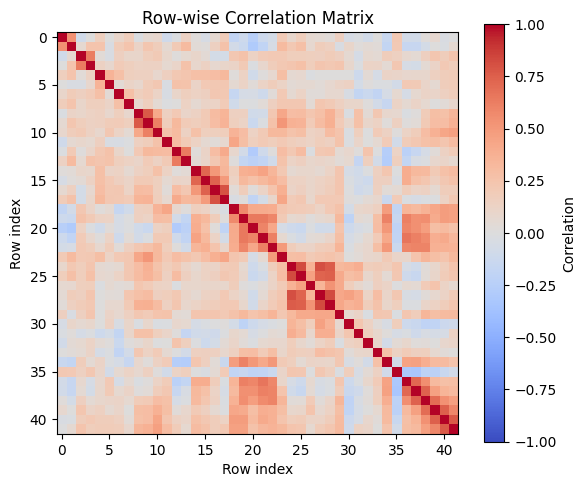

array([[ 1.        ,  0.53346297, -0.09149077, ...,  0.07354689,
        -0.03220406, -0.00645751],
       [ 0.53346297,  1.        ,  0.06885647, ...,  0.00726151,
        -0.02577538,  0.05494417],
       [-0.09149077,  0.06885647,  1.        , ...,  0.23200533,
         0.17359552,  0.24657419],
       ...,
       [ 0.07354689,  0.00726151,  0.23200533, ...,  1.        ,
         0.74335784,  0.57843547],
       [-0.03220406, -0.02577538,  0.17359552, ...,  0.74335784,
         1.        ,  0.76680358],
       [-0.00645751,  0.05494417,  0.24657419, ...,  0.57843547,
         0.76680358,  1.        ]], shape=(42, 42))

In [59]:
plot_row_correlation_matrix(sent_1_avg[lang_mask_2], title="Row-wise Correlation Matrix")

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_pca_space(
    data,
    pc_x=1,
    pc_y=2,
    title=None,
    annotate=False,
    labels=None,
    cmap="tab10",
    show_legend=True,
):
    """
    Plot rows of `data` in PCA space with optional color-coded labels.

    Parameters
    ----------
    data : array-like, shape (n_samples, n_features)
    pc_x, pc_y : int
        Principal components to plot (1-based indexing).
    title : str or None
    annotate : bool
        If True, label each point with its index.
    labels : array-like or None
        Optional labels (e.g., cluster assignments) for coloring.
        Shape: (n_samples,)
    cmap : str
        Matplotlib colormap for labels.
    show_legend : bool
        Whether to display legend when labels are provided.

    Returns
    -------
    pca : PCA object
    scores : ndarray, shape (n_samples, n_components)
    """

    data = np.asarray(data)

    if data.ndim != 2:
        raise ValueError("data must be a 2D array")

    n_samples, n_features = data.shape
    max_pc = min(n_samples, n_features)

    if not (1 <= pc_x <= max_pc and 1 <= pc_y <= max_pc):
        raise ValueError(f"pc_x and pc_y must be between 1 and {max_pc}")

    if labels is not None:
        labels = np.asarray(labels)
        if labels.shape[0] != n_samples:
            raise ValueError("labels must have same length as number of rows")

    # PCA
    pca = PCA(n_components=max_pc)
    scores = pca.fit_transform(data)

    x = scores[:, pc_x - 1]
    y = scores[:, pc_y - 1]

    plt.figure(figsize=(6, 5))

    # 🔹 Color-coded scatter
    if labels is None:
        plt.scatter(x, y)
    else:
        unique_labels = np.unique(labels)
        cmap_obj = plt.get_cmap(cmap, len(unique_labels))

        for i, lab in enumerate(unique_labels):
            idx = labels == lab
            plt.scatter(
                x[idx],
                y[idx],
                color=cmap_obj(i),
                label=f"Cluster {lab}",
                alpha=0.8,
            )

        if show_legend:
            plt.legend()

    # 🔹 Annotation
    if annotate:
        for i in range(n_samples):
            plt.text(x[i], y[i], str(i), fontsize=9)

    # 🔹 Labels
    evr = pca.explained_variance_ratio_
    plt.xlabel(f"PC{pc_x} ({evr[pc_x - 1]:.2%} var)")
    plt.ylabel(f"PC{pc_y} ({evr[pc_y - 1]:.2%} var)")

    if title is None:
        title = f"PCA space: PC{pc_x} vs PC{pc_y}"
    plt.title(title)

    plt.axhline(0)
    plt.axvline(0)
    plt.tight_layout()
    plt.show()

    return pca, scores

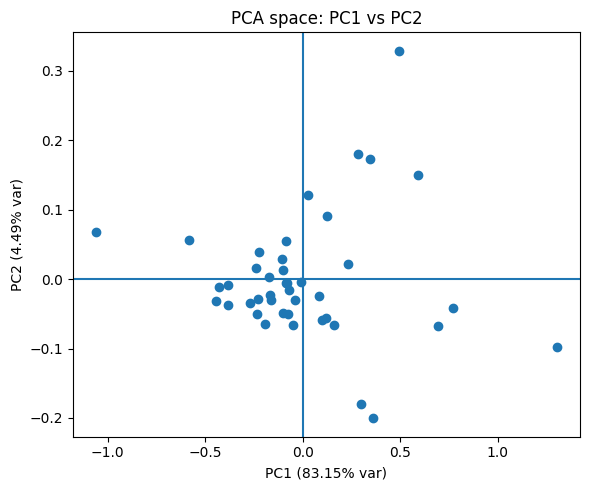

In [61]:
pca, scores = plot_pca_space(sent_2_avg[lang_mask_2], pc_x=1, pc_y=2)

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def _corr_distance_matrix(data):
    """
    Compute row-by-row correlation distance matrix: 1 - corr(row_i, row_j)
    """
    data = np.asarray(data, dtype=float)

    if data.ndim != 2:
        raise ValueError("data must be a 2D array")

    corr = np.corrcoef(data)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    corr = np.clip(corr, -1.0, 1.0)

    dist = 1.0 - corr
    np.fill_diagonal(dist, 0.0)

    return corr, dist


def _assign_points_to_medoids(dist_matrix, medoid_indices):
    """
    Assign each point to its nearest medoid.
    """
    d_to_medoids = dist_matrix[:, medoid_indices]   # shape (n, k)
    labels = np.argmin(d_to_medoids, axis=1)
    return labels


def _compute_inertia(dist_matrix, medoid_indices, labels):
    """
    Sum of distances from each point to its assigned medoid.
    """
    return np.sum(dist_matrix[np.arange(dist_matrix.shape[0]), np.array(medoid_indices)[labels]])


def _update_medoids(dist_matrix, labels, k, medoid_indices):
    """
    For each cluster, choose the point minimizing total within-cluster distance.
    """
    new_medoids = []

    for cluster_id in range(k):
        cluster_points = np.where(labels == cluster_id)[0]

        # Handle empty cluster by keeping old medoid
        if len(cluster_points) == 0:
            new_medoids.append(medoid_indices[cluster_id])
            continue

        subD = dist_matrix[np.ix_(cluster_points, cluster_points)]
        costs = subD.sum(axis=1)
        best_local = np.argmin(costs)
        new_medoids.append(cluster_points[best_local])

    return np.array(new_medoids, dtype=int)


def _kmedoids_precomputed(dist_matrix, k, max_iter=100, random_state=0, n_init=10):
    """
    Simple PAM-style K-medoids using a precomputed distance matrix.
    Returns best medoids, labels, inertia.
    """
    rng = np.random.default_rng(random_state)
    n = dist_matrix.shape[0]

    best_medoids = None
    best_labels = None
    best_inertia = np.inf

    for _ in range(n_init):
        medoids = rng.choice(n, size=k, replace=False)

        for _ in range(max_iter):
            labels = _assign_points_to_medoids(dist_matrix, medoids)
            new_medoids = _update_medoids(dist_matrix, labels, k, medoids)

            if np.array_equal(new_medoids, medoids):
                break
            medoids = new_medoids

        labels = _assign_points_to_medoids(dist_matrix, medoids)
        inertia = _compute_inertia(dist_matrix, medoids, labels)

        if inertia < best_inertia:
            best_inertia = inertia
            best_medoids = medoids.copy()
            best_labels = labels.copy()

    return best_medoids, best_labels, best_inertia


def cluster_rows_kmedoids_correlation(
    data,
    k_range=range(2, 10),
    max_iter=100,
    n_init=10,
    random_state=0,
    elbow_method="second_derivative",
    plot=True,
):
    """
    Cluster rows of `data` using K-medoids with correlation distance.

    Parameters
    ----------
    data : array-like, shape (n_rows, n_features)
    k_range : iterable of ints
        Candidate k values to test.
    max_iter : int
        Max K-medoids update iterations per run.
    n_init : int
        Number of random initializations per k.
    random_state : int
        Seed.
    elbow_method : str
        Currently supports 'second_derivative'.
    plot : bool
        Whether to plot elbow.

    Returns
    -------
    labels : ndarray, shape (n_rows,)
        Cluster labels for the best k.
    best_k : int
        Estimated elbow k.
    inertias : ndarray
        Inertia for each k.
    corr_matrix : ndarray
        Row-by-row correlation matrix.
    dist_matrix : ndarray
        Row-by-row correlation distance matrix.
    medoids : ndarray
        Medoid row indices for best solution.
    """
    data = np.asarray(data, dtype=float)

    if data.ndim != 2:
        raise ValueError("data must be 2D")

    n_rows = data.shape[0]
    k_values = list(k_range)

    if len(k_values) < 2:
        raise ValueError("k_range must contain at least two values")

    if any(k < 2 or k > n_rows for k in k_values):
        raise ValueError(f"Each k must satisfy 2 <= k <= {n_rows}")

    corr_matrix, dist_matrix = _corr_distance_matrix(data)

    all_results = []
    inertias = []

    for k in k_values:
        medoids, labels, inertia = _kmedoids_precomputed(
            dist_matrix,
            k=k,
            max_iter=max_iter,
            n_init=n_init,
            random_state=random_state,
        )
        all_results.append((k, medoids, labels, inertia))
        inertias.append(inertia)

    inertias = np.array(inertias, dtype=float)

    # Estimate elbow
    if elbow_method == "second_derivative":
        if len(inertias) < 3:
            best_idx = int(np.argmin(inertias))
        else:
            second_diff = np.diff(inertias, n=2)
            best_idx = np.argmin(second_diff) + 1
    else:
        raise ValueError("Unsupported elbow_method")

    best_k, medoids, labels, _ = all_results[best_idx]

    if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(k_values, inertias, marker="o")
        plt.axvline(best_k, linestyle="--", label=f"estimated elbow: k={best_k}")
        plt.xlabel("Number of clusters (k)")
        plt.ylabel("K-medoids objective")
        plt.title("Elbow plot: K-medoids with correlation distance")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return labels, best_k, inertias, corr_matrix, dist_matrix, medoids

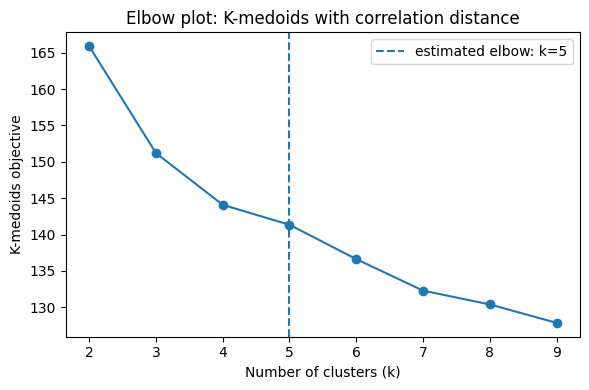

Best k: 5
Labels: [3 3 3 3 3 3 3 3 2 4 2 1 1 3 3 3 3 3 3 3 1 1 0 0 0 0 3 2 3 3 3 3 3 3 3 3 3
 3 0 0 0 0 0 0 0 0 0 1 2 4 3 0 0 0 0 0 0 0 2 1 3 3 3 3 3 4 4 4 2 3 2 0 3 4
 4 2 2 2 4 4 4 4 4 2 4 3 3 3 4 4 2 4 4 2 2 4 4 4 2 4 4 4 3 3 3 3 3 0 4 0 0
 0 3 3 0 0 1 2 2 2 4 2 2 4 4 4 2 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 2 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 2 2 2 4 4 4 3 2 0 2 1 4 1 0 1 2 1
 4 4 2 4 2 0 4 4 2 0 2 2 2 4 4 2 2 2 2 2 0 4 2 4 1 1 1 3 1 1 1 4 4 4 2 4 4
 4 4 4 2 2]


In [72]:
labels, best_k, inertias, corr_matrix, dist_matrix, medoids = cluster_rows_kmedoids_correlation(
    sent_2_avg,
    k_range=range(2, 10),
    random_state=42,
)
print("Best k:", best_k)
print("Labels:", labels)

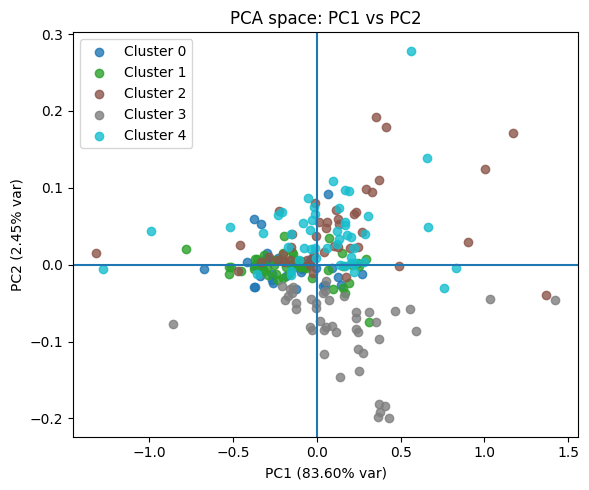

array([[1.        , 0.05286157],
       [0.05286157, 1.        ]])

In [73]:
pca, scores = plot_pca_space(sent_2_avg, pc_x=1, pc_y=2, labels=labels)
np.corrcoef(scores[:,0][lang_mask_2],scores[:,1][lang_mask_2])

In [74]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rows_together(
    data,
    title="All Rows",
    alpha=0.8,
    linewidth=1,
    mean_line=True,
    mean_color="k",
    mean_width=3,
):
    """
    Plot all rows of a matrix on the same axes.

    Parameters
    ----------
    data : array-like, shape (n_rows, n_time)
    title : str
    alpha : float
        Transparency for individual lines
    linewidth : float
        Width of individual lines
    mean_line : bool
        Whether to plot the average across rows
    mean_color : str
        Color of mean line
    mean_width : float
        Width of mean line
    """

    data = np.asarray(data)

    if data.ndim != 2:
        raise ValueError("data must be 2D (n_rows, n_time)")

    plt.figure(figsize=(7, 4))

    # Plot all rows (transpose so time is x-axis)
    plt.plot(data.T, alpha=alpha, linewidth=linewidth)

    # Plot mean
    if mean_line:
        mean_trace = data.mean(axis=0)
        plt.plot(mean_trace, color=mean_color, linewidth=mean_width)

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(title)

    plt.tight_layout()
    plt.show()

In [79]:
plot_rows_together(sent_2_avg[lang_mask_2][scores[:,0]>0.1])


IndexError: boolean index did not match indexed array along axis 0; size of axis is 42 but size of corresponding boolean axis is 227

IndexError: boolean index did not match indexed array along axis 0; size of axis is 42 but size of corresponding boolean axis is 227

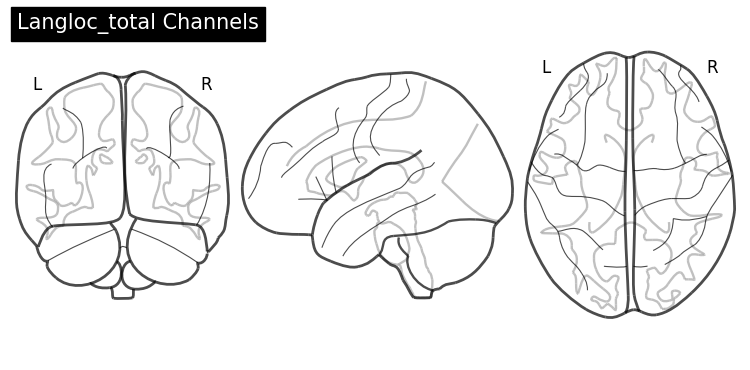

In [76]:
plot_glass_brain_masks(coordinates[lang_mask_2], 
                       [labels==0,labels==1,labels==2,labels==3,labels==4,labels==5], 
                       ["blue","green","purple","pink","olive","cyan"], 
                       ["0","1","2","3","4","5"],
                       s=12,
                       title="Langloc_total Channels")


In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.cm import ScalarMappable
from nilearn import plotting

def plot_glass_brain_scalar(
    coords,
    values,
    cmap="coolwarm",
    vmin=None,
    vmax=None,
    center=None,
    symmetric=False,
    s=20,
    title="Glass Brain",
    colorbar=True,
):
    """
    Plot electrode coordinates on a glass brain, colored by a scalar value.

    Parameters
    ----------
    coords : np.ndarray, shape (n_channels, 3)
        MNI coordinates for each electrode.
    values : array-like, shape (n_channels,)
        Scalar value for each electrode.
    cmap : str or Colormap
        Colormap to use. Default is a diverging map.
    vmin, vmax : float or None
        Color scale limits. If None, uses min/max of `values`.
    center : float or None
        Optional center value for diverging normalization.
        If provided, uses TwoSlopeNorm centered at this value.
    symmetric : bool
        If True, set vmin/vmax symmetrically around `center` if provided,
        otherwise around 0.
    s : int or float
        Scatter marker size.
    title : str
        Plot title.
    colorbar : bool
        Whether to display a colorbar.

    Returns
    -------
    display : nilearn display object
    norm : matplotlib norm object
    """
    coords = np.asarray(coords, dtype=float)
    values = np.asarray(values, dtype=float)

    if coords.ndim != 2 or coords.shape[1] != 3:
        raise ValueError("coords must have shape (n_channels, 3)")
    if values.ndim != 1:
        raise ValueError("values must be a 1D array")
    if len(values) != len(coords):
        raise ValueError("values must have the same length as coords")

    finite_mask = np.isfinite(values)
    if not np.any(finite_mask):
        raise ValueError("values contains no finite entries")

    vals_finite = values[finite_mask]

    # Default scaling: use provided vector min/max
    if vmin is None:
        vmin = vals_finite.min()
    if vmax is None:
        vmax = vals_finite.max()

    # Optional symmetric scaling
    if symmetric:
        c = 0.0 if center is None else center
        radius = max(abs(vals_finite.min() - c), abs(vals_finite.max() - c))
        vmin = c - radius
        vmax = c + radius

    if center is not None:
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
    else:
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    cmap_obj = plt.get_cmap(cmap)

    # compute depth-based alpha per electrode
    z_all = coords[:, 2]
    z_norm = (z_all - z_all.min()) / (z_all.max() - z_all.min() + 1e-8)

    x_all = coords[:, 0]
    ax_alpha = 0.2 + 0.8 * (1 - (x_all - x_all.min()) / (x_all.max() - x_all.min() + 1e-8))
    cor_alpha = 0.2 + 0.8 * z_norm
    axi_alpha = 0.2 + 0.8 * np.abs(z_norm - 0.5) * 2

    display = plotting.plot_glass_brain(
        None,
        display_mode="ortho",
        title=title
    )

    ax_x = display.axes["x"].ax  # sagittal: y vs z
    ax_x.invert_xaxis()
    ax_y = display.axes["y"].ax  # coronal: x vs z
    ax_z = display.axes["z"].ax  # axial: x vs y

    for i in range(len(coords)):
        if not np.isfinite(values[i]):
            continue

        x, y, z = coords[i]
        color = cmap_obj(norm(values[i]))

        ax_x.scatter(y, z, s=s, c=[color], alpha=ax_alpha[i])
        ax_y.scatter(x, z, s=s, c=[color], alpha=cor_alpha[i])
        ax_z.scatter(x, y, s=s, c=[color], alpha=axi_alpha[i])
    
    if colorbar:
        sm = ScalarMappable(norm=norm, cmap=cmap_obj)
        sm.set_array([])

        # manual axis for colorbar (right side)
        cax = plt.gcf().add_axes([1.05, 0.15, 0.02, 0.7])  
        cbar = plt.colorbar(sm, cax=cax)
        cbar.set_label("Value")

    plt.show()
    return display, norm

In [71]:
plot_glass_brain_scalar(coordinates[lang_mask_2], scores[:,1], cmap="coolwarm", center=0, symmetric=True)

ValueError: values must have the same length as coords

In [ ]:
plt.plot(sent_2_avg.mean(axis=1),scores[:,0],'o')
print(np.corrcoef(sent_2_avg.mean(axis=1),scores[:,0])[0,1])

In [67]:
slopes = row_slopes(sent_2_avg[:,0:60])

NameError: name 'row_slopes' is not defined

In [68]:
plt.plot(slopes,scores[:,1],'o')
print(np.corrcoef(slopes,scores[:,1])[0,1])

NameError: name 'slopes' is not defined

## Lateralization Analysis

In [ ]:
ch_names = np.asarray(raw.pick('seeg').ch_names)[~ied_mask]
L_mask = np.char.startswith(ch_names, "L")
L_ch_names = ch_names[L_mask]

Estimate proportion of lang electrodes for each test

In [ ]:
n_langloc1 =  np.sum(is_language_responsive_1)
n_langloc1_left = np.sum(is_language_responsive_1 & L_mask)
percent_langloc1_left = np.round(n_langloc1_left/n_langloc1*100,2)

print(f"Number of left-lateralized language channels from langloc 1: {n_langloc1_left }/{n_langloc1} channels")
print(f"{percent_langloc1_left}% of all language channels from langloc1 are left lateralized")

n_langloc2 =  np.sum(is_language_responsive_2)
n_langloc2_left = np.sum(is_language_responsive_2 & L_mask)
percent_langloc2_left = np.round(n_langloc2_left/n_langloc2*100,2)

print(f"Number of left-lateralized language channels from langloc 2: {n_langloc2_left }/{n_langloc2} channels")
print(f"{percent_langloc2_left}% of all language channels from langloc2 are left lateralized")

n_langloc_t =  np.sum(is_language_responsive_t)
n_langloc_t_left = np.sum(is_language_responsive_t & L_mask)
percent_langloc_t_left = np.round(n_langloc_t_left/n_langloc_t*100,2)

print(f"Number of left-lateralized language channels from both langlocs: {n_langloc_t_left }/{n_langloc_t} channels")
print(f"{percent_langloc_t_left}% of all language channels from both langlocs are left lateralized")

### Lateralized reliability analysis

In [ ]:
lang2_corrs_left    = split_half_reliability(reliability_matrix_1[is_language_responsive_2&L_mask])
nonlang2_corrs_left = split_half_reliability(reliability_matrix_1[~is_language_responsive_2&L_mask])
results2_left = bootstrap_language_significance(lang2_corrs_left, nonlang2_corrs_left)

print("Left Hemisphere Reliability - Langloc 2")
print(f"observed={results2_left['observed_mean']:.3f}, p={results2_left['p_value']:.4f}")
print(f"null={results2_left['null_mean']:.3f}, bounds=[{results2_left['null_lower']:.3f},{results2_left['null_upper']:.3f}]")

lang2_corrs_right    = split_half_reliability(reliability_matrix_1[is_language_responsive_2& ~L_mask])
nonlang2_corrs_right = split_half_reliability(reliability_matrix_1[~is_language_responsive_2& ~L_mask])
results2_right = bootstrap_language_significance(lang2_corrs_right, nonlang2_corrs_right)

print("Right Hemisphere Reliability - Langloc 2")
print(f"observed={results2_right['observed_mean']:.3f}, p={results2_right['p_value']:.4f}")
print(f"null={results2_right['null_mean']:.3f}, bounds=[{results2_right['null_lower']:.3f},{results2_right['null_upper']:.3f}]")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bins = 30

for ax, lang_corrs, nonlang_corrs, results, title in [
    (axes[0], lang2_corrs_left, nonlang2_corrs_left, results2_left, "Langloc2 Left-Hemi Split-Half Reliability"),
    (axes[1], lang2_corrs_right, nonlang2_corrs_right, results2_right, "Langloc2 Right-Hemi Split-Half Reliability"),
]:
    lang_r    = lang_corrs
    nonlang_r = nonlang_corrs

    ax.hist(nonlang_r, bins=bins, color="gray", alpha=0.6, label="Non-language")
    ax.hist(lang_r,    bins=bins, color="red",  alpha=0.6, label="Language")

    ax.axvline(nonlang_r.mean(), color="black", linestyle="--", linewidth=2)
    ax.axvline(lang_r.mean(),    color="red",   linestyle="--", linewidth=2)

    ax.axvspan(
        results["null_lower"], results["null_upper"],
        alpha=0.25, color="black", label="Null 95% CI"
    )

    ax.set_title(title)
    ax.set_xlabel("Reliability (r)")
    ax.set_ylabel("Number of Channels")
    ax.legend(
        title=f"p={results['p_value']:.4f}",
        title_fontsize=9
    )

plt.tight_layout()
plt.show()

## Other plots

#### Plot Good vs Bad Electrodes

In [ ]:
seeg_picks = mne.pick_types(raw.info, seeg=True)
seeg_names = [raw.ch_names[i] for i in seeg_picks]

montage = raw.get_montage()

if montage is not None:
    positions = montage.get_positions()["ch_pos"]
    coordinates = np.array([positions[ch] for ch in seeg_names if ch in positions])
else:
    coordinates = np.array([
        raw.info["chs"][i]["loc"][:3]
        for i in seeg_picks
    ])


In [ ]:
plot_glass_brain_masks(coordinates, 
                       [~ied_mask,ied_mask], 
                       ["green","orange"], 
                       ["good","bad (high-IED)"],
                       s=12,
                       title="Good and bad channels")
plot_glass_brain_masks(coordinates, 
                       [ied_mask], 
                       ["orange"], 
                       ["bad (high-IED)"],
                       s=12,
                       title="Bad only channels")

# Control: Reruning Experiments without filtering IED


In [ ]:
langloc1_trials, _ = get_trial_word_boundaries_from_block(langloc1)
langloc2_trials, _ = get_trial_word_boundaries_from_block(langloc2)

In [ ]:
envelope_data = prep_raw.get_data(picks="misc")
n_channels, _ = envelope_data.shape
n_channels

##### process trials into condition average responses

In [ ]:
langloc1_respvec, langloc1_respvec_ideal = compute_response_vector(langloc1_trials, envelope_data, langloc_dict)
langloc2_respvec, langloc2_respvec_ideal = compute_response_vector(langloc2_trials, envelope_data, langloc_dict)

##### determine language channels via permuation test

In [ ]:
#results from each langloc
true_corrs_1, null_corrs_1, p_values_1, is_language_responsive_1, thresholds_95_1 = fast_langloc_permutation_test(langloc1_respvec, langloc1_respvec_ideal, n_perm=10000, seed=42)
true_corrs_2, null_corrs_2, p_values_2, is_language_responsive_2, thresholds_95_2 = fast_langloc_permutation_test(langloc2_respvec, langloc2_respvec_ideal, n_perm=10000, seed=42)


#results from both langlocs combine
langloc_respvec_t = np.concatenate([langloc1_respvec,langloc2_respvec], axis = 1)
langloc_respvec_ideal_t = np.concatenate([langloc1_respvec_ideal,langloc2_respvec_ideal], axis = 0)
true_corrs_t, null_corrs_t, p_values_t, is_language_responsive_t, thresholds_95_t = fast_langloc_permutation_test(langloc_respvec_t, langloc_respvec_ideal_t, n_perm=10000, seed=42)



print(f"Language Channels found using langloc 1: {is_language_responsive_1.sum()} channels")
print(f"Language Channels found using langloc 2: {is_language_responsive_2.sum()} channels")
print(f"Language Channels found using both langlocs: {is_language_responsive_t.sum()} channels")
print()
print(f"Overlap between langloc 1 and langloc 2: {np.sum(is_language_responsive_1&is_language_responsive_2)} channels")
print(f"Overlap between langloc 1 and langloc_both: {np.sum(is_language_responsive_1&is_language_responsive_t)} channels")
print(f"Overlap between langloc 2 and langloc_both: {np.sum(is_language_responsive_t&is_language_responsive_2)} channels")


##### plot language electrode

In [ ]:
plot_glass_brain_masks(coordinates, 
                       [is_language_responsive_1,~is_language_responsive_1], 
                       ["red","blue"], 
                       ["language","non-language"],
                       s=12,
                       title="Langloc1 Channels")
plot_glass_brain_masks(coordinates, 
                       [is_language_responsive_1], 
                       ["red"], 
                       ["language"],
                       s=12,
                       title="Langloc1 (lang only) Channels")

In [ ]:
plot_glass_brain_masks(coordinates, 
                       [is_language_responsive_2,~is_language_responsive_2], 
                       ["red","blue"], 
                       ["language","non-language"],
                       s=12,
                       title="Langloc2 Channels")
plot_glass_brain_masks(coordinates, 
                       [is_language_responsive_2], 
                       ["red"], 
                       ["language"],
                       s=12,
                       title="Langloc2 (lang only) Channels")



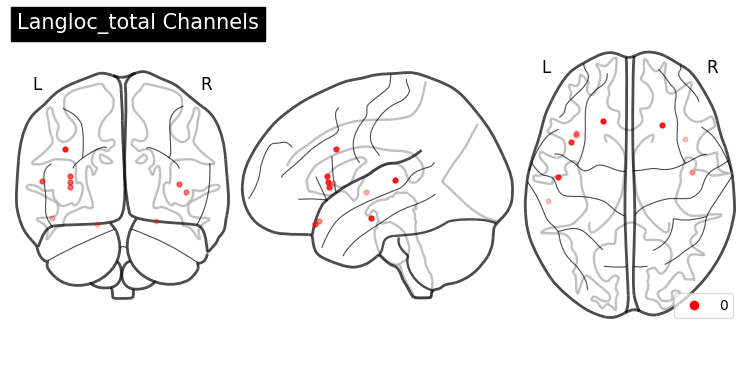

#### Reliability Analysis
##### Reliability Matrix

In [ ]:

reliability_matrix_1, pair_indices_1, min_condition_samples_1 = build_greedy_reliability_matrix(
    trials=langloc1_trials,
    envelope_data=envelope_data,
    langloc_dict=langloc_dict,
)

reliability_matrix_2, pair_indices_2, min_condition_samples_2 = build_greedy_reliability_matrix(
    trials=langloc2_trials,
    envelope_data=envelope_data,
    langloc_dict=langloc_dict,
)


print(reliability_matrix_1.shape)
print(reliability_matrix_2.shape)

##### Split-Half Reliability

In [ ]:

lang1_corrs    = split_half_reliability(reliability_matrix_2[is_language_responsive_1])
nonlang1_corrs = split_half_reliability(reliability_matrix_2[~is_language_responsive_1])

results1 = bootstrap_language_significance(lang1_corrs, nonlang1_corrs)

print(f"observed={results1['observed_mean']:.3f}, p={results1['p_value']:.4f}")
print(f"null={results1['null_mean']:.3f}, bounds=[{results1['null_lower']:.3f},{results1['null_upper']:.3f}]")

lang2_corrs    = split_half_reliability(reliability_matrix_1[is_language_responsive_2])
nonlang2_corrs = split_half_reliability(reliability_matrix_1[~is_language_responsive_2])

results2 = bootstrap_language_significance(lang2_corrs, nonlang2_corrs)

print(f"observed={results2['observed_mean']:.3f}, p={results2['p_value']:.4f}")
print(f"null={results2['null_mean']:.3f}, bounds=[{results2['null_lower']:.3f},{results2['null_upper']:.3f}]")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bins = 30

for ax, lang_corrs, nonlang_corrs, results, title in [
    (axes[0], lang1_corrs, nonlang1_corrs, results1, "Langloc1 Split-Half Reliability"),
    (axes[1], lang2_corrs, nonlang2_corrs, results2, "Langloc2 Split-Half Reliability"),
]:
    lang_r    = lang_corrs
    nonlang_r = nonlang_corrs

    ax.hist(nonlang_r, bins=bins, color="gray", alpha=0.6, label="Non-language")
    ax.hist(lang_r,    bins=bins, color="red",  alpha=0.6, label="Language")

    ax.axvline(nonlang_r.mean(), color="black", linestyle="--", linewidth=2)
    ax.axvline(lang_r.mean(),    color="red",   linestyle="--", linewidth=2)

    ax.axvspan(
        results["null_lower"], results["null_upper"],
        alpha=0.25, color="black", label="Null 95% CI"
    )

    ax.set_title(title)
    ax.set_xlabel("Reliability (r)")
    ax.set_ylabel("Number of Channels")
    ax.legend(
        title=f"p={results['p_value']:.4f}",
        title_fontsize=9
    )

plt.tight_layout()
plt.show()

#### Lateralization Analysis

In [ ]:
ch_names = np.asarray(raw.pick('seeg').ch_names)
L_mask = np.char.startswith(ch_names, "L")
L_ch_names = ch_names[L_mask]


In [ ]:


n_langloc1 =  np.sum(is_language_responsive_1)
n_langloc1_left = np.sum(is_language_responsive_1 & L_mask)
percent_langloc1_left = np.round(n_langloc1_left/n_langloc1*100,2)

print(f"Number of left-lateralized language channels from langloc 1: {n_langloc1_left }/{n_langloc1} channels")
print(f"{percent_langloc1_left}% of all language channels from langloc1 are left lateralized")

n_langloc2 =  np.sum(is_language_responsive_2)
n_langloc2_left = np.sum(is_language_responsive_2 & L_mask)
percent_langloc2_left = np.round(n_langloc2_left/n_langloc2*100,2)

print(f"Number of left-lateralized language channels from langloc 2: {n_langloc2_left }/{n_langloc2} channels")
print(f"{percent_langloc2_left}% of all language channels from langloc2 are left lateralized")

n_langloc_t =  np.sum(is_language_responsive_t)
n_langloc_t_left = np.sum(is_language_responsive_t & L_mask)
percent_langloc_t_left = np.round(n_langloc_t_left/n_langloc_t*100,2)

print(f"Number of left-lateralized language channels from both langlocs: {n_langloc_t_left }/{n_langloc_t} channels")
print(f"{percent_langloc_t_left}% of all language channels from both langlocs are left lateralized")



##### Lateralized reliability analysis

In [ ]:


lang2_corrs_left    = split_half_reliability(reliability_matrix_1[is_language_responsive_2&L_mask])
nonlang2_corrs_left = split_half_reliability(reliability_matrix_1[~is_language_responsive_2&L_mask])
results2_left = bootstrap_language_significance(lang2_corrs_left, nonlang2_corrs_left)

print("Left Hemisphere Reliability - Langloc 2")
print(f"observed={results2_left['observed_mean']:.3f}, p={results2_left['p_value']:.4f}")
print(f"null={results2_left['null_mean']:.3f}, bounds=[{results2_left['null_lower']:.3f},{results2_left['null_upper']:.3f}]")

lang2_corrs_right    = split_half_reliability(reliability_matrix_1[is_language_responsive_2& ~L_mask])
nonlang2_corrs_right = split_half_reliability(reliability_matrix_1[~is_language_responsive_2& ~L_mask])
results2_right = bootstrap_language_significance(lang2_corrs_right, nonlang2_corrs_right)

print("Right Hemisphere Reliability - Langloc 2")
print(f"observed={results2_right['observed_mean']:.3f}, p={results2_right['p_value']:.4f}")
print(f"null={results2_right['null_mean']:.3f}, bounds=[{results2_right['null_lower']:.3f},{results2_right['null_upper']:.3f}]")


In [ ]:

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bins = 30

for ax, lang_corrs, nonlang_corrs, results, title in [
    (axes[0], lang2_corrs_left, nonlang2_corrs_left, results2_left, "Langloc2 Left-Hemi Split-Half Reliability"),
    (axes[1], lang2_corrs_right, nonlang2_corrs_right, results2_right, "Langloc2 Right-Hemi Split-Half Reliability"),
]:
    lang_r    = lang_corrs
    nonlang_r = nonlang_corrs

    ax.hist(nonlang_r, bins=bins, color="gray", alpha=0.6, label="Non-language")
    ax.hist(lang_r,    bins=bins, color="red",  alpha=0.6, label="Language")

    ax.axvline(nonlang_r.mean(), color="black", linestyle="--", linewidth=2)
    ax.axvline(lang_r.mean(),    color="red",   linestyle="--", linewidth=2)

    ax.axvspan(
        results["null_lower"], results["null_upper"],
        alpha=0.25, color="black", label="Null 95% CI"
    )

    ax.set_title(title)
    ax.set_xlabel("Reliability (r)")
    ax.set_ylabel("Number of Channels")
    ax.legend(
        title=f"p={results['p_value']:.4f}",
        title_fontsize=9
    )

plt.tight_layout()
plt.show()

# coordinates of different sets

In [ ]:
good_idx = mne.pick_types(prep_raw.info, misc=True, exclude="bads")

In [ ]:
def expand_mask_to_full(
    mask: np.ndarray,        # 1D bool/int array of length n_good
    good_indices: np.ndarray, # 1D int array of indices into the full channel space
    n_total: int             # total number of channels (good + bad)
) -> np.ndarray:
    """
    Expand a mask defined over good channels to the full channel space.
    Bad channels and non-language channels are both set to 0.

    Parameters
    ----------
    mask         : 1D array of length n_good (bool or int)
    good_indices : 1D int array of length n_good — indices into full channel list
    n_total      : total number of channels in the full space

    Returns
    -------
    np.ndarray of shape (n_total,), dtype int, with 0s for bad/non-language channels
    """
    assert len(mask) == len(good_indices), (
        f"mask length {len(mask)} != good_indices length {len(good_indices)}"
    )

    full_mask = np.zeros(n_total, dtype=int)
    full_mask[good_indices] = np.asarray(mask).astype(int)
    return full_mask


def expand_masks_to_full(
    masks: list,             # list of 1D arrays, each length n_good
    good_indices: np.ndarray,
    n_total: int
) -> list:
    """Convenience wrapper to expand a list of masks."""
    return [expand_mask_to_full(m, good_indices, n_total) for m in masks]

please use the correct language responsive voxels (filter out ied)

In [ ]:
is_lang_1 = expand_mask_to_full(is_language_responsive_1, good_idx, 255)
is_lang_2 = expand_mask_to_full(is_language_responsive_2, good_idx, 255)
is_lang_t = expand_mask_to_full(is_language_responsive_t, good_idx, 255)

In [ ]:
import numpy as np
import pandas as pd
import mne

def build_electrode_csv(
    raw: mne.io.BaseRaw,
    masks: list,           # list of 1D bool/int arrays, each length n_channels
    mask_ids: list,        # list of str column labels, same length as masks
    output_path: str = None
) -> pd.DataFrame:
    """
    Build a DataFrame (and optionally save CSV) with one row per channel,
    containing channel name, x/y/z coordinates, and binary language mask columns.

    Parameters
    ----------
    raw       : MNE Raw object with a montage set
    masks     : list of 1D arrays (bool or int), each of length n_channels
    mask_ids  : list of str — column label for each mask
    output_path : if provided, saves the CSV to this path

    Returns
    -------
    pd.DataFrame
    """
    assert len(masks) == len(mask_ids), "masks and mask_ids must have the same length"

    # --- Channel names ---
    ch_names = raw.info["ch_names"]
    n_channels = len(ch_names)

    # --- XYZ coordinates from montage ---
    montage = raw.get_montage()
    if montage is None:
        raise ValueError("No montage is set on this Raw object.")

    # get_positions() returns dict with 'ch_pos': {name: [x, y, z]}
    ch_pos = montage.get_positions()["ch_pos"]

    coords = {"x": [], "y": [], "z": []}
    for ch in ch_names:
        pos = ch_pos.get(ch, [np.nan, np.nan, np.nan])
        coords["x"].append(pos[0])
        coords["y"].append(pos[1])
        coords["z"].append(pos[2])

    # --- Assemble DataFrame ---
    df = pd.DataFrame({"channel": ch_names, **coords})

    for mask_id, mask in zip(mask_ids, masks):
        mask_arr = np.asarray(mask)
        assert len(mask_arr) == n_channels, (
            f"Mask '{mask_id}' has length {len(mask_arr)}, expected {n_channels}"
        )
        df[mask_id] = mask_arr.astype(int)  # bool -> 0/1

    # --- Save ---
    if output_path is not None:
        df.to_csv(output_path, index=False)
        print(f"Saved to {output_path}")

    return df

In [ ]:
mask_ids = ["langloc_1", "langloc_2", "langloc_total"]
masks    = [is_lang_1, is_lang_2, is_lang_t]          # each shape (n_channels,)
langloc_csv_path = Path("/storage/cedar/cedar_cos/cos-lab-aivanova7/eayesh3/iEEG/EMOP0004/tasks_raw/sub_EMOP0004_langloc_coords.csv")

df = build_electrode_csv(
    raw=raw,
    masks=masks,
    mask_ids=mask_ids,
    output_path=langloc_csv_path
)